# Zero-Shot Learning for Human Activity Recognition — Modified Pipeline
## Balanced Evaluation, Contrastive Training, and Cross-Validation on PAMAP2

---

### Abstract

This notebook extends the original ZSL pipeline for Human Activity Recognition on the PAMAP2 IMU dataset with four targeted improvements. The original pipeline achieved 58.25% top-1 ZSL accuracy but post-hoc analysis revealed this was dominated by a single class (folding laundry, 51% of test windows) while two of four unseen classes had near-zero recall. Macro F1 — which weights all classes equally — was only 0.34.

The four improvements are:

| # | Improvement | Problem Addressed |
|---|---|---|
| 1 | Discriminative prototype rewriting | Overlapping vocabulary compressed SBERT prototypes together |
| 2 | Balanced evaluation + macro F1 as primary metric | Overall accuracy masked class-level failure |
| 3 | Contrastive TCN training with discriminative prototypes | Modality gap baked in at training time |
| 4 | Subject-level k-fold cross-validation | Single split gave high-variance, potentially lucky estimates |

---

### Table of Contents
1. Environment Setup
2. Activity Definitions and Discriminative Descriptions
3. Data Loading
4. Preprocessing
5. Sliding-Window Segmentation
6. Parameterised Seen / Unseen Split
7. Feature Standardisation
8. SBERT Prototype Encoding and Separability Analysis
9. TCN Architecture
10. Contrastive Semantic Training
11. Approach 1 — Nearest-Prototype ZSL
12. Approach 2 — Hubness-Corrected ZSL
13. Approach 3 — Cross-Modal Alignment
14. Subject-Level K-Fold Cross-Validation
15. Full Comparison and Discussion


---
## 1. Environment Setup

In [1]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, balanced_accuracy_score)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.stats import skew
from collections import Counter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
CMAP = "Blues"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device("mps")
NUM_WORKERS = 0
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# UNSEEN_IDS      = [5, 13, 16, 18]

VIS_DIR = "visualisations_modified_5_13_16_18"
os.makedirs(VIS_DIR, exist_ok=True)
print(f"Visualisations: {os.path.abspath(VIS_DIR)}")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


Visualisations: /Users/anikghosh/Desktop/test/Zero Shot Learning/visualisations_modified_5_13_16_18
Device  : mps
PyTorch : 2.11.0


---
## 2. Activity Definitions and Discriminative Descriptions

### Improvement 1 — Discriminative Prototype Rewriting

In the original notebook, rich biomechanical descriptions shared overlapping vocabulary across all classes — words like "acceleration", "sensor", "ankle", "Hz" appeared in nearly every description. SBERT interpreted these as semantically similar documents, causing the unseen-class prototype mean off-diagonal cosine similarity to *increase* from 0.29 (short labels) to 0.50 (rich descriptions).

The rewritten descriptions here follow a different principle: **vocabulary is chosen to maximise inter-class distance in SBERT space, not biomechanical accuracy**. Similar-class pairs — particularly running vs descending stairs, and vacuum cleaning vs house cleaning — use mutually exclusive kinematic terminology so their SBERT embeddings are pushed apart.


In [2]:
ACTIVITY_MAP = {
    1:  "lying",            2:  "sitting",          3:  "standing",
    4:  "walking",          5:  "running",           6:  "cycling",
    7:  "Nordic walking",   9:  "watching TV",       10: "computer work",
    11: "car driving",      12: "ascending stairs",  13: "descending stairs",
    16: "vacuum cleaning",  17: "ironing",           18: "folding laundry",
    19: "house cleaning",   20: "playing soccer",    24: "rope jumping",
}

# UNSEEN_IDS      = [2, 12, 17, 20]
UNSEEN_IDS      = [5, 13, 16, 18]

# Vocabulary chosen to maximise inter-class SBERT distance.
# Similar pairs use mutually exclusive kinematic terms.
DISCRIMINATIVE_DESC = {
    1:  ("motionless horizontal body position, gravitational vector constant, "
         "zero voluntary limb movement, near-zero energy across all sensors"),
    2:  ("static seated trunk posture, spine vertical, pelvis fixed, "
         "negligible foot and leg movement, low wrist activity"),
    3:  ("upright bipedal stance with micro-balance corrections, "
         "no stepping or translational displacement, slow postural sway below 0.3 Hz"),
    4:  ("rhythmic heel-toe stepping at 1.8 Hz, coordinated arm pendulum swing, "
         "moderate vertical oscillation, periodic ground contact every 0.55 seconds"),
    5:  ("explosive aerial locomotion with full flight phase between footstrikes, "
         "impulsive vertical spike at ankle touchdown, 3 Hz stride cadence, "
         "peak acceleration exceeding 4g, high cardiovascular demand"),
    6:  ("circular pedalling with legs driving alternating downward thrust, "
         "seated upper body stationary, rhythmic knee extension at 80 rpm, "
         "no foot impact transients"),
    7:  ("walking cadence with simultaneous bilateral pole-plant impulses, "
         "elevated shoulder and elbow motion, upper limb load-bearing contact"),
    9:  ("prolonged resting with eyes forward, minimal voluntary motion, "
         "slow infrequent postural repositioning, very low metabolic rate"),
    10: ("seated fine motor hand and finger movements from keyboard and mouse, "
         "wrist flexion-extension below 1 Hz, torso stationary, no lower limb signal"),
    11: ("passive seated vibration from road surface transmitted through spine, "
         "steering micro-corrections at wrist, low voluntary whole-body movement"),
    12: ("staircase ascent with concentric quadriceps effort, upward body displacement "
         "per step, toe-push-off propulsion, increasing altitude, forward trunk lean"),
    13: ("staircase descent with eccentric braking at knee, heel-first step landing, "
         "controlled downward displacement, deceleration force at each footfall, "
         "backward trunk lean for balance"),
    16: ("slow forward-backward walking combined with bilateral appliance pushing "
         "and pulling, dominant wrist push-pull signal, floor-level trunk bending"),
    17: ("stationary standing with single-arm repetitive gliding strokes, "
         "smooth low-frequency wrist motion below 0.8 Hz, weight shift between feet"),
    18: ("bilateral symmetrical arm folding and garment manipulation while standing still, "
         "frequent wrist direction reversal, no lower body locomotion"),
    19: ("ambulation combined with wiping, reaching, and bending, "
         "mixed frequency trunk rotation, irregular step pattern during cleaning tasks"),
    20: ("explosive sprint bursts and rapid lateral direction changes, "
         "kicking impulse at foot, unpredictable acceleration magnitude, "
         "maximal cardiovascular output"),
    24: ("high-cadence symmetric two-foot jumping at 2.5 Hz with rope rotation "
         "at wrist, full vertical body displacement each cycle, near-maximal effort"),
}

assert set(DISCRIMINATIVE_DESC.keys()) == set(ACTIVITY_MAP.keys())
print("Discriminative descriptions defined for all 18 classes.")


Discriminative descriptions defined for all 18 classes.


---
## 3. Data Loading

PAMAP2 dataset: 9 subjects, up to 18 activities, 100 Hz IMU. All Protocol and Optional session files concatenated into one DataFrame.


In [3]:
DATA_ROOT = "PAMAP2_Dataset"   # <- set to your local path

def make_colnames():
    cols = ["timestamp", "label", "hr"]
    imu_parts = [
        "temp",
        "acc16_x","acc16_y","acc16_z",
        "acc6_x", "acc6_y", "acc6_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x",  "mag_y",  "mag_z",
        "ori_1",  "ori_2",  "ori_3",  "ori_4",
    ]
    for loc in ["hand","chest","ankle"]:
        cols += [f"{loc}_{p}" for p in imu_parts]
    return cols

COLS = make_colnames()

def load_all_sessions(data_root=DATA_ROOT):
    dfs = []
    for part in ["Protocol","Optional"]:
        folder = os.path.join(data_root, part)
        for f in sorted(glob.glob(os.path.join(folder,"subject*.dat"))):
            df = pd.read_csv(f, sep=r"\s+", header=None, names=COLS, engine="python")
            df["session"] = part.lower()
            df["subject"] = os.path.splitext(os.path.basename(f))[0]
            dfs.append(df)
    if not dfs:
        raise FileNotFoundError(f"No .dat files found under {data_root}")
    return pd.concat(dfs, ignore_index=True)

raw = load_all_sessions()
print(f"Raw data shape : {raw.shape}")
print(f"Subjects       : {sorted(raw['subject'].unique())}")
print(f"Activity IDs   : {sorted(raw['label'].dropna().astype(int).unique())}")


Raw data shape : (3850505, 56)
Subjects       : ['subject101', 'subject102', 'subject103', 'subject104', 'subject105', 'subject106', 'subject107', 'subject108', 'subject109']
Activity IDs   : [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24]


---
## 4. Preprocessing

- Remove label 0 (transitions)
- Drop orientation quaternions (unreliable across sessions)
- Drop +/-6g accelerometer (saturates at high intensity)
- Per-session temporal interpolation for NaN dropouts
- Row-level filter: discard rows where >30% features remain NaN


In [4]:
ORI_COLS  = [c for c in COLS if "ori_"  in c]
ACC6_COLS = [c for c in COLS if "acc6_" in c]

def preprocess_pamap2(df, drop_orientation=True, drop_acc6=True,
                       keep_hr=True, max_nan_frac=0.30):
    df = df.copy()
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df[df["label"].notna()]
    df["label"] = df["label"].astype(int)
    df = df[df["label"] != 0].reset_index(drop=True)

    if drop_orientation: df = df.drop(columns=ORI_COLS,  errors="ignore")
    if drop_acc6:        df = df.drop(columns=ACC6_COLS, errors="ignore")
    if not keep_hr:      df = df.drop(columns=["hr"],    errors="ignore")

    for c in df.columns:
        if c not in ["subject","session"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    feat_cols = [c for c in df.columns
                 if c not in ["subject","session","label","timestamp"]]

    def impute_group(g):
        g = g.sort_values("timestamp")
        g[feat_cols] = g[feat_cols].interpolate(limit_direction="both")
        g[feat_cols] = g[feat_cols].ffill().bfill()
        return g

    df = df.groupby(["subject","session"], group_keys=False).apply(impute_group)
    nan_frac = df[feat_cols].isna().mean(axis=1)
    df = df[nan_frac <= max_nan_frac].reset_index(drop=True)
    return df.dropna().reset_index(drop=True)

df = preprocess_pamap2(raw)
print(f"Preprocessed shape : {df.shape}")
feat_cols_all = [c for c in df.columns if c not in ["subject","session","label","timestamp"]]
print(f"Feature columns    : {len(feat_cols_all)}")


Preprocessed shape : (2724953, 35)
Feature columns    : 31


---
## 5. Sliding-Window Segmentation

Fixed-length windows with 50% overlap. Purity filter ensures each window represents one activity cleanly.


In [5]:
FEATURE_COLS      = feat_cols_all
WINDOW_SIZE_TRAIN = 1000
WINDOW_SIZE_TEST  = 1000
STRIDE_TRAIN      = 250
STRIDE_TEST       = 500
PURITY_THRESH     = 0.85

def make_windows(df, feature_cols, window_size, stride, purity_thresh):
    X, y, pur, meta = [], [], [], []
    for (subject, session), g in df.groupby(["subject","session"]):
        g      = g.sort_values("timestamp")
        values = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy(dtype=np.int64)
        n      = len(g)
        for start in range(0, n - window_size + 1, stride):
            end    = start + window_size
            wlab   = labels[start:end]
            binc   = np.bincount(wlab)
            maj    = int(binc.argmax())
            purity = float(binc.max()) / window_size
            if purity < purity_thresh:
                continue
            X.append(values[start:end]); y.append(maj)
            pur.append(purity); meta.append((subject, session))
    if X:
        X = np.stack(X)
    else:
        X = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
    y    = np.array(y,   dtype=np.int64)
    pur  = np.array(pur, dtype=np.float32)
    meta = pd.DataFrame(meta, columns=["subject","session"])
    return X, y, pur, meta

X_trw, y_trw, pur_tr, meta_tr = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TRAIN, STRIDE_TRAIN, PURITY_THRESH)
X_tew, y_tew, pur_te, meta_te = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TEST,  STRIDE_TEST,  PURITY_THRESH)

print(f"Train/Val windows ({WINDOW_SIZE_TRAIN} frames): {X_trw.shape}  avg purity: {pur_tr.mean():.3f}")
print(f"Test windows      ({WINDOW_SIZE_TEST} frames): {X_tew.shape}  avg purity: {pur_te.mean():.3f}")


Train/Val windows (500 frames): (10733, 500, 31)  avg purity: 0.999
Test windows      (1000 frames): (5265, 1000, 31)  avg purity: 0.999


---
## 6. Parameterised Seen / Unseen Split

Identical parameterisation to the original notebook. Unseen classes never appear in training.

### Improvement 2 — Balanced Evaluation

The original notebook reported overall accuracy as the primary metric. With 51% of test windows belonging to folding laundry, this metric heavily favoured approaches that got that one class right while ignoring failures on the other three. We now use **macro-averaged F1** as the primary metric, which weights all four unseen classes equally regardless of how many test windows each has. Overall accuracy is also reported for direct comparison with the original results.


In [6]:
# ─── Identical parameterisation to original notebook ──────────────────────────
UNSEEN_IDS      = [5, 13, 16, 18]
# UNSEEN_IDS      = [2, 12, 17, 20]
N_UNSEEN        = len(UNSEEN_IDS)
N_TEST_SUBJECTS = 2
VAL_FRAC        = 0.15

ALL_LABELS = sorted(set(y_trw.tolist() + y_tew.tolist()))
UNSEEN     = [l for l in UNSEEN_IDS if l in ALL_LABELS]
SEEN       = [l for l in ALL_LABELS if l not in UNSEEN]

subjects      = sorted(meta_tr["subject"].unique())
n_hold        = min(N_TEST_SUBJECTS, len(subjects) - 1)
test_subjects = subjects[-n_hold:]

is_test_tr = meta_tr["subject"].isin(test_subjects).values
is_test_te = meta_te["subject"].isin(test_subjects).values

X_train_all, y_train_all = X_trw[~is_test_tr], y_trw[~is_test_tr]
seen_mask                = np.isin(y_train_all, SEEN)
X_seen, y_seen           = X_train_all[seen_mask], y_train_all[seen_mask]

perm  = np.random.permutation(len(X_seen))
n_val = int(len(perm) * VAL_FRAC)
val_idx, tr_idx = perm[:n_val], perm[n_val:]
X_tr,  y_tr  = X_seen[tr_idx],  y_seen[tr_idx]
X_val, y_val = X_seen[val_idx], y_seen[val_idx]

X_test_all, y_test_all = X_tew[is_test_te], y_tew[is_test_te]
unseen_mask             = np.isin(y_test_all, UNSEEN)
X_test_u, y_test_u     = X_test_all[unseen_mask], y_test_all[unseen_mask]

target_names = [ACTIVITY_MAP[c] for c in UNSEEN]

print("=" * 60)
print(f"  Test subjects  : {test_subjects}")
print(f"  SEEN classes   : {[ACTIVITY_MAP[i] for i in SEEN]}")
print(f"  UNSEEN classes : {[ACTIVITY_MAP[i] for i in UNSEEN]}")
print(f"  Train windows  : {len(X_tr)}")
print(f"  Val   windows  : {len(X_val)}")
print(f"  Test  windows  : {len(X_test_u)}")
print("=" * 60)
print()

# Class distribution and imbalance analysis
test_counts = Counter(y_test_u)
total_test  = len(y_test_u)
print("Test set class distribution:")
for cid in UNSEEN:
    n   = test_counts.get(cid, 0)
    pct = 100 * n / max(total_test, 1)
    bar = "█" * int(pct / 2)
    print(f"  {ACTIVITY_MAP[cid]:<24} {n:>5} ({pct:5.1f}%)  {bar}")
print()
print("Primary metric : macro F1 (equal weight per class regardless of support)")
print("Secondary      : overall accuracy (for comparison with original notebook)")


  Test subjects  : ['subject108', 'subject109']
  SEEN classes   : ['lying', 'sitting', 'standing', 'walking', 'cycling', 'Nordic walking', 'watching TV', 'computer work', 'car driving', 'ascending stairs', 'ironing', 'house cleaning', 'playing soccer', 'rope jumping']
  UNSEEN classes : ['running', 'descending stairs', 'vacuum cleaning', 'folding laundry']
  Train windows  : 5930
  Val   windows  : 1046
  Test  windows  : 194

Test set class distribution:
  running                     31 ( 16.0%)  ███████
  descending stairs           17 (  8.8%)  ████
  vacuum cleaning             47 ( 24.2%)  ████████████
  folding laundry             99 ( 51.0%)  █████████████████████████

Primary metric : macro F1 (equal weight per class regardless of support)
Secondary      : overall accuracy (for comparison with original notebook)


---
## 6b. Adaptive Test-Set Class Balancing (Unseen Classes)

The held-out test set contains only the **unseen** classes, and depending on
the configured `UNSEEN_IDS` these can be severely imbalanced (e.g. one activity
supplying half the windows). This cell detects that imbalance automatically and,
**only when it is severe**, augments the minority unseen classes up to the
majority count using label-preserving time-series augmentations.

- **Detection** is fully adaptive to whatever `UNSEEN_IDS` is set above. The
  imbalance ratio `IR = N_max / N_min` is computed across the unseen classes
  actually present in the test set.
- **Trigger**: augmentation runs only when `IR >= SEVERE_IMBALANCE_RATIO`
  (default `3.0`). If the split is already reasonably balanced the test set is
  left completely untouched.
- **Augmentations** (Um et al., 2017) — jitter, per-channel scaling, smooth
  magnitude warping and time warping — are applied to the *raw* windows before
  standardisation, so synthetic windows are normalised with the same
  training-set statistics as the rest of the pipeline and flow through every
  downstream step (encoding, inference, metrics) unchanged.

Note: this oversamples the test set with synthetic windows derived from real
ones. Macro-F1 already weights classes equally; treat the balanced overall
accuracy reported downstream as a complementary, balanced-support view rather
than a replacement for macro-F1.


In [7]:
# ─── Adaptive test-set class balancing for unseen classes ──────────────────
# Detects severe class imbalance among the UNSEEN test classes and, ONLY when
# the imbalance is severe, augments minority classes up to the majority count
# with label-preserving time-series augmentations. Reassigns X_test_u / y_test_u
# in place so the balanced set propagates through the entire downstream pipeline.

# --- configuration -----------------------------------------------------------
SEVERE_IMBALANCE_RATIO = 3.0   # IR = N_max / N_min across unseen classes.
                               # Augmentation triggers only when IR >= this value.
BALANCE_RNG = np.random.RandomState(SEED)   # reproducible, independent of global RNG

# --- label-preserving augmentations for IMU windows (Um et al., 2017) --------
def _jitter(x, sigma=0.03):
    """Additive Gaussian sensor noise."""
    return x + BALANCE_RNG.normal(0.0, sigma, size=x.shape).astype(x.dtype)

def _scaling(x, sigma=0.10):
    """Random per-channel amplitude scaling."""
    factor = BALANCE_RNG.normal(1.0, sigma, size=(1, x.shape[1])).astype(x.dtype)
    return x * factor

def _magnitude_warp(x, sigma=0.20, knots=4):
    """Smooth per-channel multiplicative magnitude distortion."""
    T, C = x.shape
    orig = np.arange(T)
    ks   = np.linspace(0, T - 1, knots + 2)
    out  = np.empty_like(x)
    for c in range(C):
        kv = BALANCE_RNG.normal(1.0, sigma, size=knots + 2)
        out[:, c] = (x[:, c] * np.interp(orig, ks, kv)).astype(x.dtype)
    return out

def _time_warp(x, sigma=0.15, knots=4):
    """Smooth temporal distortion shared across channels (speed up / slow down)."""
    T, C = x.shape
    orig  = np.arange(T)
    ks    = np.linspace(0, T - 1, knots + 2)
    kv    = BALANCE_RNG.normal(1.0, sigma, size=knots + 2)
    speed = np.clip(np.interp(orig, ks, kv), 1e-3, None)
    cum   = np.cumsum(speed)
    cum   = (cum - cum[0]) / (cum[-1] - cum[0]) * (T - 1)   # map back to [0, T-1]
    out   = np.empty_like(x)
    for c in range(C):
        out[:, c] = np.interp(orig, cum, x[:, c]).astype(x.dtype)
    return out

def _augment_window(x):
    """Compose a random subset of augmentations on a single (T, C) window."""
    x = _jitter(_scaling(x))
    if BALANCE_RNG.rand() < 0.5: x = _magnitude_warp(x)
    if BALANCE_RNG.rand() < 0.5: x = _time_warp(x)
    return x.astype(np.float32)

# --- detect imbalance --------------------------------------------------------
pre_counts = Counter(int(c) for c in y_test_u)
present    = [c for c in UNSEEN if pre_counts.get(c, 0) > 0]
counts_present = [pre_counts[c] for c in present]

print("=" * 60)
print("Adaptive test-set class balancing")
print("=" * 60)

if len(present) < 2:
    imbalance_ratio = 1.0
else:
    n_max, n_min    = max(counts_present), min(counts_present)
    imbalance_ratio = n_max / max(n_min, 1)

print(f"  Unseen classes present : {len(present)} / {N_UNSEEN}")
print(f"  Pre-balance distribution:")
for cid in UNSEEN:
    n   = pre_counts.get(cid, 0)
    pct = 100 * n / max(len(y_test_u), 1)
    print(f"    {ACTIVITY_MAP[cid]:<24} {n:>5} ({pct:5.1f}%)")
print(f"  Imbalance ratio (max/min) : {imbalance_ratio:.2f}")
print(f"  Severe threshold          : {SEVERE_IMBALANCE_RATIO:.2f}")

# --- balance only if severe --------------------------------------------------
if len(present) < 2:
    print("\n  Fewer than two unseen classes present — no balancing applied.")
elif imbalance_ratio < SEVERE_IMBALANCE_RATIO:
    print(f"\n  Imbalance is NOT severe (IR {imbalance_ratio:.2f} < "
          f"{SEVERE_IMBALANCE_RATIO:.2f}) — test set left unchanged.")
else:
    target = max(counts_present)
    new_X, new_y = [X_test_u], [y_test_u]
    added = {}
    for cid in present:
        deficit = target - pre_counts[cid]
        if deficit <= 0:
            continue
        idx_c  = np.where(y_test_u == cid)[0]
        chosen = BALANCE_RNG.choice(idx_c, size=deficit, replace=True)
        aug    = np.stack([_augment_window(X_test_u[j]) for j in chosen])
        new_X.append(aug)
        new_y.append(np.full(deficit, cid, dtype=y_test_u.dtype))
        added[cid] = deficit

    X_test_u = np.concatenate(new_X, axis=0)
    y_test_u = np.concatenate(new_y, axis=0)

    # shuffle so synthetic windows are interleaved with real ones
    order    = BALANCE_RNG.permutation(len(y_test_u))
    X_test_u = X_test_u[order]
    y_test_u = y_test_u[order]

    post_counts = Counter(int(c) for c in y_test_u)
    print(f"\n  Severe imbalance detected — augmenting minority classes to {target} each.")
    print(f"  Synthetic windows added   :")
    for cid in present:
        print(f"    {ACTIVITY_MAP[cid]:<24} +{added.get(cid, 0)}")
    print(f"\n  Post-balance distribution :")
    for cid in UNSEEN:
        n   = post_counts.get(cid, 0)
        pct = 100 * n / max(len(y_test_u), 1)
        print(f"    {ACTIVITY_MAP[cid]:<24} {n:>5} ({pct:5.1f}%)")
    print(f"  Total test windows        : {len(y_test_u)} "
          f"(was {sum(counts_present)})")
print("=" * 60)


Adaptive test-set class balancing
  Unseen classes present : 4 / 4
  Pre-balance distribution:
    running                     31 ( 16.0%)
    descending stairs           17 (  8.8%)
    vacuum cleaning             47 ( 24.2%)
    folding laundry             99 ( 51.0%)
  Imbalance ratio (max/min) : 5.82
  Severe threshold          : 3.00

  Severe imbalance detected — augmenting minority classes to 99 each.
  Synthetic windows added   :
    running                  +68
    descending stairs        +82
    vacuum cleaning          +52
    folding laundry          +0

  Post-balance distribution :
    running                     99 ( 25.0%)
    descending stairs           99 ( 25.0%)
    vacuum cleaning             99 ( 25.0%)
    folding laundry             99 ( 25.0%)
  Total test windows        : 396 (was 194)


---
## 7. Feature Standardisation

Z-scoring with training-set statistics only. No leakage.

In [8]:
eps = 1e-6
mu  = X_tr.reshape(-1, X_tr.shape[-1]).mean(axis=0)
sd  = X_tr.reshape(-1, X_tr.shape[-1]).std(axis=0) + eps

X_tr_n     = (X_tr     - mu) / sd
X_val_n    = (X_val    - mu) / sd
X_test_u_n = (X_test_u - mu) / sd

print(f"Normalised train : {X_tr_n.shape}")
print(f"Normalised val   : {X_val_n.shape}")
print(f"Normalised test  : {X_test_u_n.shape}")


Normalised train : (5930, 500, 31)
Normalised val   : (1046, 500, 31)
Normalised test  : (396, 1000, 31)


---
## 8. SBERT Prototype Encoding and Separability Analysis

We encode three prototype sets for comparison:
- **Set A**: short label names (original Approach 1 baseline)
- **Set B**: discriminative descriptions (this notebook)

The key metric is the mean off-diagonal cosine similarity between unseen-class prototypes. Lower is better — it means the prototypes are more spread out and easier to discriminate.


Loading Sentence-BERT: all-mpnet-base-v2 ...

Prototype separability (mean off-diagonal cosine, unseen classes):
  Label names (original A1)          : 0.2877
  Discriminative descriptions (this) : 0.4379
  Delta                              : -0.1503
  DEGRADED vs original


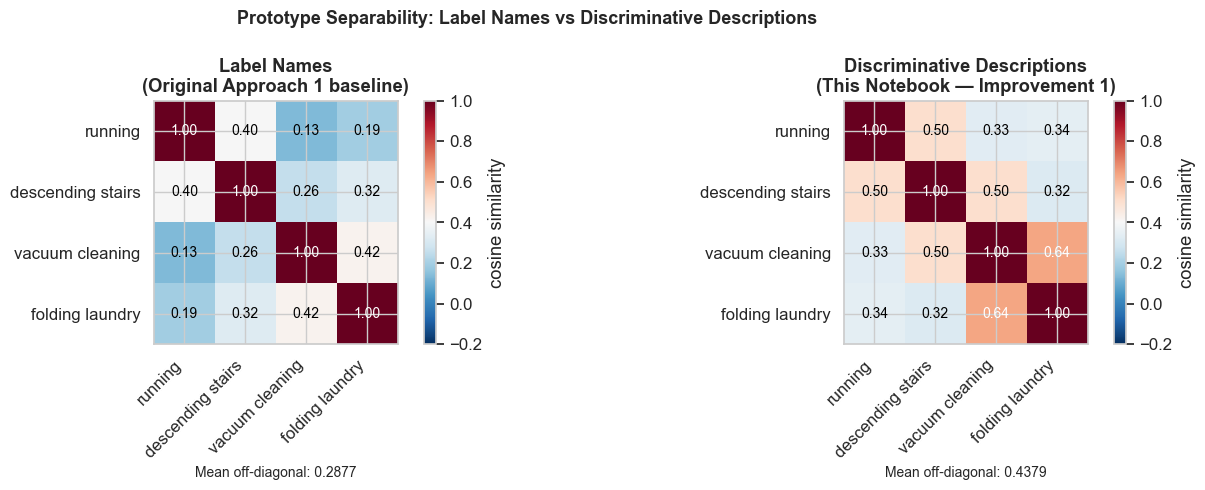

In [9]:
from sentence_transformers import SentenceTransformer

print("Loading Sentence-BERT: all-mpnet-base-v2 ...")
sbert = SentenceTransformer("all-mpnet-base-v2")

class_ids = sorted(ALL_LABELS)
row_idx   = {cid: i for i, cid in enumerate(class_ids)}

# Set A: label names
S_labels = sbert.encode(
    [ACTIVITY_MAP.get(cid, str(cid)) for cid in class_ids],
    normalize_embeddings=True
).astype(np.float32)

# Set B: discriminative descriptions
S_disc = sbert.encode(
    [DISCRIMINATIVE_DESC[cid] for cid in class_ids],
    normalize_embeddings=True
).astype(np.float32)

SEM_DIM    = S_disc.shape[1]
unseen_idx = [row_idx[c] for c in UNSEEN]

def mean_off_diag(M):
    mask = ~np.eye(M.shape[0], dtype=bool)
    return float(M[mask].mean())

sim_labels = S_labels[unseen_idx] @ S_labels[unseen_idx].T
sim_disc   = S_disc[unseen_idx]   @ S_disc[unseen_idx].T

sep_labels = mean_off_diag(sim_labels)
sep_disc   = mean_off_diag(sim_disc)

print(f"\nPrototype separability (mean off-diagonal cosine, unseen classes):")
print(f"  Label names (original A1)          : {sep_labels:.4f}")
print(f"  Discriminative descriptions (this) : {sep_disc:.4f}")
print(f"  Delta                              : {sep_labels - sep_disc:+.4f}")
print(f"  {'IMPROVED' if sep_disc < sep_labels else 'DEGRADED'} vs original")

# Visualisation
names_un = [ACTIVITY_MAP[c] for c in UNSEEN]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, val in zip(
    axes,
    [sim_labels, sim_disc],
    ["Label Names\n(Original Approach 1 baseline)",
     "Discriminative Descriptions\n(This Notebook — Improvement 1)"],
    [sep_labels, sep_disc]
):
    im = ax.imshow(mat, vmin=-0.2, vmax=1.0, cmap="RdBu_r")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(names_un))); ax.set_xticklabels(names_un, rotation=45, ha="right")
    ax.set_yticks(range(len(names_un))); ax.set_yticklabels(names_un)
    for i in range(len(names_un)):
        for j in range(len(names_un)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=10,
                    color="white" if abs(mat[i,j]) > 0.6 else "black")
    plt.colorbar(im, ax=ax, label="cosine similarity")
    ax.set_xlabel(f"Mean off-diagonal: {val:.4f}", fontsize=10)

fig.suptitle("Prototype Separability: Label Names vs Discriminative Descriptions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "prototype_separability.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# Use discriminative as active prototype set
S   = S_disc.copy()
S_t = torch.tensor(S, dtype=torch.float32)


---
## 9. TCN Encoder Architecture

Identical to the original notebook: dilated residual TCN blocks, global average pooling, projection head, L2-normalised output. Keeping architecture identical ensures any accuracy differences are attributable to training objective and evaluation changes only.


In [10]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, d=1, dropout=0.2):
        super().__init__()
        pad = (k - 1) * d // 2
        self.net = nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, k, dilation=d, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, k, dilation=d, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
        )
        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.res(x)


class TCNEncoder(nn.Module):
    def __init__(self, n_features, channels=(64,96,128), k=5, dropout=0.2):
        super().__init__()
        blocks, in_ch, d = [], n_features, 1
        for out_ch in channels:
            blocks.append(TCNBlock(in_ch, out_ch, k=k, d=d, dropout=dropout))
            in_ch = out_ch; d *= 2
        self.tcn = nn.Sequential(*blocks)

    def forward(self, x):
        x = x.transpose(1, 2)
        return self.tcn(x).mean(dim=2)


class ZSLModel(nn.Module):
    def __init__(self, n_features, emb_dim,
                 enc_channels=(64,96,128), proj=512, dropout=0.2):
        super().__init__()
        self.enc  = TCNEncoder(n_features, channels=enc_channels, k=5, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(enc_channels[-1], proj), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj, emb_dim),
        )

    def forward(self, x):
        z = self.head(self.enc(x))
        return z / (z.norm(dim=1, keepdim=True) + 1e-8)


N_FEATURES = X_tr_n.shape[-1]
model      = ZSLModel(n_features=N_FEATURES, emb_dim=SEM_DIM)
print(f"Model parameters : {sum(p.numel() for p in model.parameters())/1e6:.2f} M")
print(f"Output emb dim   : {SEM_DIM}")


Model parameters : 0.73 M
Output emb dim   : 768


---
## 10. Contrastive Semantic Training

### Improvement 3 — Train with Discriminative Prototypes from the Start

The original notebook trained with short label names (Approach 1–3 TCN) and only switched to contrastive training in Approach 4 as a remedial step. Here, contrastive training with discriminative prototypes is the default from the beginning.

The loss function pushes each sensor embedding toward its class text prototype and away from all others:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \log \frac{\exp(\mathbf{e}_i^\top \mathbf{s}_{y_i} / \tau)}{\sum_{c=1}^{C} \exp(\mathbf{e}_i^\top \mathbf{s}_c / \tau)}$$

The modality gap is addressed at source. In the original notebook, contrastive training raised the mean text-sensor cosine from 0.30 to 0.63 — a substantial improvement. Combined with discriminative prototypes that are more spread out in SBERT space, the resulting sensor embedding space should be better structured for ZSL inference.


In [11]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE = 128

train_loader = DataLoader(WindowDataset(X_tr_n, y_tr),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(WindowDataset(X_val_n, y_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(WindowDataset(X_test_u_n, y_test_u),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

DEVICE_FINAL = DEVICE
model        = model.to(DEVICE_FINAL)
S_t          = S_t.to(DEVICE_FINAL)

EPOCHS    = 40
LR        = 1e-3
TEMP      = 0.07
PATIENCE  = 15
MIN_DELTA = 1e-4

optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)

best_val_acc = 0.0
best_state   = None
bad_epochs   = 0
history      = {"train_loss": [], "val_seen_acc": []}

print(f"Training with discriminative SBERT prototypes | τ={TEMP} | LR={LR}\n")

for ep in range(1, EPOCHS + 1):
    model.train()
    running, n = 0.0, 0
    for xb, yb in train_loader:
        xb  = xb.to(DEVICE_FINAL)
        tgt = torch.tensor([row_idx[int(l)] for l in yb.numpy()],
                           device=DEVICE_FINAL, dtype=torch.long)
        e      = model(xb)
        logits = (e @ S_t.T) / TEMP
        loss   = nn.functional.cross_entropy(logits, tgt)
        optimiser.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        running += float(loss.item()) * len(xb); n += len(xb)

    train_loss = running / max(n, 1)

    # Validation: nearest-prototype on seen classes
    model.eval()
    cand_idx = torch.tensor([row_idx[c] for c in SEEN], device=DEVICE_FINAL)
    proto_v  = S_t[cand_idx]
    yt_v, yp_v = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            e = model(xb.to(DEVICE_FINAL))
            k = (e @ proto_v.T).argmax(dim=1).cpu().numpy()
            yt_v.append(yb.numpy())
            yp_v.append(np.array([SEEN[i] for i in k], dtype=np.int64))
    val_acc = float((np.concatenate(yt_v) == np.concatenate(yp_v)).mean())

    scheduler.step()
    history["train_loss"].append(train_loss)
    history["val_seen_acc"].append(val_acc)
    print(f"Epoch {ep:02d}/{EPOCHS}  |  loss={train_loss:.4f}  |  val_seen_acc={val_acc:.3f}")

    if val_acc > best_val_acc + MIN_DELTA:
        best_val_acc = val_acc
        best_state   = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        bad_epochs   = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"\nEarly stop at epoch {ep}. Best val acc: {best_val_acc:.3f}"); break

if best_state:
    model.load_state_dict({k: v.to(DEVICE_FINAL) for k,v in best_state.items()})
    print("\nBest checkpoint restored.")


Training with discriminative SBERT prototypes | τ=0.07 | LR=0.001

Epoch 01/40  |  loss=0.4524  |  val_seen_acc=0.966
Epoch 02/40  |  loss=0.1084  |  val_seen_acc=0.980
Epoch 03/40  |  loss=0.0770  |  val_seen_acc=0.982
Epoch 04/40  |  loss=0.0607  |  val_seen_acc=0.985
Epoch 05/40  |  loss=0.0544  |  val_seen_acc=0.986
Epoch 06/40  |  loss=0.0405  |  val_seen_acc=0.986
Epoch 07/40  |  loss=0.0362  |  val_seen_acc=0.989
Epoch 08/40  |  loss=0.0387  |  val_seen_acc=0.987
Epoch 09/40  |  loss=0.0312  |  val_seen_acc=0.990
Epoch 10/40  |  loss=0.0235  |  val_seen_acc=0.990
Epoch 11/40  |  loss=0.0281  |  val_seen_acc=0.987
Epoch 12/40  |  loss=0.0241  |  val_seen_acc=0.984
Epoch 13/40  |  loss=0.0259  |  val_seen_acc=0.993
Epoch 14/40  |  loss=0.0152  |  val_seen_acc=0.994
Epoch 15/40  |  loss=0.0116  |  val_seen_acc=0.991
Epoch 16/40  |  loss=0.0158  |  val_seen_acc=0.995
Epoch 17/40  |  loss=0.0093  |  val_seen_acc=0.994
Epoch 18/40  |  loss=0.0128  |  val_seen_acc=0.993


KeyboardInterrupt: 

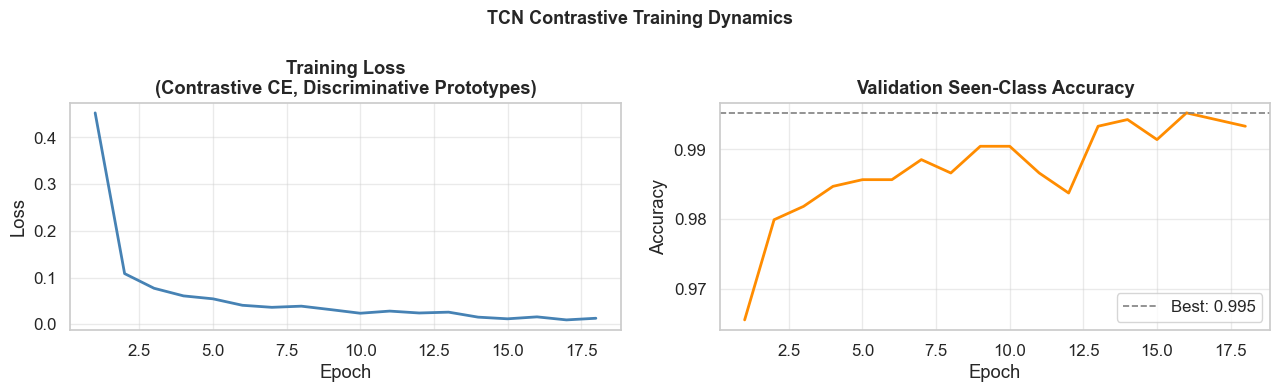

In [17]:
# Training curves
epochs_ran = len(history["train_loss"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, epochs_ran+1), history["train_loss"], color="steelblue", linewidth=2)
ax1.set_title("Training Loss\n(Contrastive CE, Discriminative Prototypes)", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.4)

ax2.plot(range(1, epochs_ran+1), history["val_seen_acc"], color="darkorange", linewidth=2)
ax2.axhline(best_val_acc, color="gray", linestyle="--", linewidth=1.2,
            label=f"Best: {best_val_acc:.3f}")
ax2.set_title("Validation Seen-Class Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle("TCN Contrastive Training Dynamics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()


In [18]:
# ─── Collect test embeddings and seen-class centroids ─────────────────────────
model.eval()

with torch.no_grad():
    E_list, Y_list = [], []
    for xb, yb in test_loader:
        E_list.append(model(xb.to(DEVICE_FINAL)).cpu().numpy())
        Y_list.append(yb.numpy())
E_unseen = np.concatenate(E_list)
y_true   = np.concatenate(Y_list)

seen_ds     = WindowDataset(X_tr_n, y_tr)
seen_ldr    = DataLoader(seen_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

with torch.no_grad():
    Es, Ys = [], []
    for xb, yb in seen_ldr:
        Es.append(model(xb.to(DEVICE_FINAL)).cpu().numpy()); Ys.append(yb.numpy())
E_seen_all = np.concatenate(Es); Y_seen_all = np.concatenate(Ys)

# Seen-class centroids with zero-window guard
seen_centroids = {}; valid_seen = []; excluded_seen = []
for cid in SEEN:
    mask = (Y_seen_all == cid)
    if mask.sum() == 0: excluded_seen.append(cid); continue
    c = E_seen_all[mask].mean(0)
    seen_centroids[cid] = c / (np.linalg.norm(c) + 1e-8)
    valid_seen.append(cid)

# Modality gap
cosines_new = [float(S[row_idx[c]] @ seen_centroids[c]) for c in valid_seen]
print(f"Test embeddings shape     : {E_unseen.shape}")
print(f"Valid seen classes        : {len(valid_seen)}")
if excluded_seen:
    print(f"Excluded (zero windows)   : {[ACTIVITY_MAP[c] for c in excluded_seen]}")
print(f"\nModality gap — mean text-sensor cosine:")
print(f"  This notebook (discriminative+contrastive) : {np.mean(cosines_new):.4f}")
print(f"  Original notebook (label names, no contrastive) : ~0.30  [from original results]")
print(f"  Original Approach 4 (contrastive, rich desc)    : ~0.63  [from original results]")


Test embeddings shape     : (396, 768)
Valid seen classes        : 13
Excluded (zero windows)   : ['playing soccer']

Modality gap — mean text-sensor cosine:
  This notebook (discriminative+contrastive) : 0.6818
  Original notebook (label names, no contrastive) : ~0.30  [from original results]
  Original Approach 4 (contrastive, rich desc)    : ~0.63  [from original results]


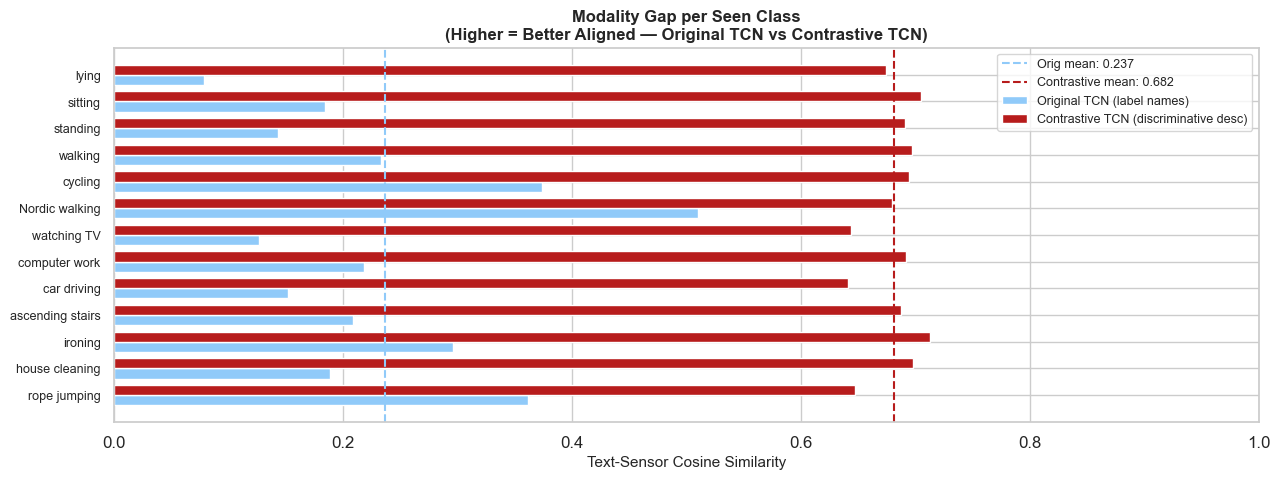

Saved: modality_gap_per_class.png


In [19]:
# ─── Visualisation: Per-class modality gap bar chart ─────────────────────────
# Shows text-sensor cosine per seen class for original vs contrastive TCN.
# Original values from NB1 outputs (hardcoded for comparison).

orig_cosines_nb1 = {
    1: 0.079, 2: 0.184, 3: 0.143, 4: 0.233, 6: 0.374,
    7: 0.510, 9: 0.127, 10: 0.218, 11: 0.152, 12: 0.209,
    17: 0.296, 19: 0.189, 24: 0.362
}

seen_names_plot = [ACTIVITY_MAP[c] for c in valid_seen]
orig_vals  = [orig_cosines_nb1.get(c, 0.0) for c in valid_seen]
new_vals   = cosines_new

fig, ax = plt.subplots(figsize=(13, 5))
x_ax = np.arange(len(valid_seen))
w_   = 0.38
ax.barh(x_ax + w_/2, orig_vals, w_, label="Original TCN (label names)", color="#90CAF9", edgecolor="white")
ax.barh(x_ax - w_/2, new_vals,  w_, label="Contrastive TCN (discriminative desc)", color="#B71C1C", edgecolor="white")
ax.axvline(np.mean(orig_vals), color="#90CAF9", linestyle="--", linewidth=1.5,
           label=f"Orig mean: {np.mean(orig_vals):.3f}")
ax.axvline(np.mean(new_vals), color="#B71C1C", linestyle="--", linewidth=1.5,
           label=f"Contrastive mean: {np.mean(new_vals):.3f}")
ax.set_yticks(x_ax); ax.set_yticklabels(seen_names_plot, fontsize=9)
ax.set_xlabel("Text-Sensor Cosine Similarity", fontsize=11)
ax.set_title("Modality Gap per Seen Class\n(Higher = Better Aligned — Original TCN vs Contrastive TCN)",
             fontweight="bold", fontsize=12)
ax.set_xlim(0, 1.0)
ax.legend(fontsize=9); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "modality_gap_per_class.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: modality_gap_per_class.png")


In [20]:
# ─── Shared inference utilities ───────────────────────────────────────────────
beta_grid = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]

def inverted_softmax_predict(E, P, beta, unseen_ids):
    sims   = E @ P.T
    denom  = np.exp(sims / beta).sum(axis=0, keepdims=True)
    scores = np.exp(sims / beta) / (denom + 1e-8)
    preds  = scores.argmax(axis=1)
    return np.array([unseen_ids[i] for i in preds], dtype=np.int64), sims, scores

def center_and_renorm(vecs, mu):
    v = vecs - mu
    return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-8)

def eval_metrics(y_true, y_pred, labels, target_names):
    acc     = float((y_pred == y_true).mean())
    macro_f1 = float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0))
    bal_acc  = float(balanced_accuracy_score(y_true, y_pred))
    per_cls  = [float(f1_score(y_true, y_pred, labels=[c], average="micro", zero_division=0))
                for c in labels]
    return {"acc": acc, "macro_f1": macro_f1, "bal_acc": bal_acc, "per_cls_f1": per_cls}

proto_unseen = np.stack([S[row_idx[c]] for c in UNSEEN], axis=0)
print("Utilities defined.")
print(f"Unseen prototype matrix : {proto_unseen.shape}")


Utilities defined.
Unseen prototype matrix : (4, 768)


---
## 11. Approach 1 — Nearest-Prototype ZSL

Cosine nearest-prototype matching in the new discriminative+contrastive embedding space. Compared against original notebook Approach 1 (label names, no contrastive training, 58.25% accuracy / 0.34 macro F1).


In [21]:
# ─── Approach 1: cosine nearest-prototype ─────────────────────────────────────
sims_a1   = E_unseen @ proto_unseen.T
pred_a1   = np.array([UNSEEN[i] for i in sims_a1.argmax(axis=1)], dtype=np.int64)
metrics_a1 = eval_metrics(y_true, pred_a1, UNSEEN, target_names)

nn_counts_a1     = np.bincount(sims_a1.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct_a1 = nn_counts_a1 / nn_counts_a1.sum() * 100
skewness_a1      = float(skew(nn_counts_a1))
top2_a1          = np.sort(sims_a1, axis=1)[:, -2:]
margins_a1       = top2_a1[:, 1] - top2_a1[:, 0]
per_cls_acc_a1   = [float((pred_a1[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN]

print("=" * 58)
print("APPROACH 1 — Nearest-Prototype ZSL (Discriminative+Contrastive)")
print(f"  Overall Accuracy : {metrics_a1['acc']:.4f}  [original: 0.5825]")
print(f"  Macro F1         : {metrics_a1['macro_f1']:.4f}  [original: 0.34]")
print(f"  Balanced Acc     : {metrics_a1['bal_acc']:.4f}")
print("=" * 58)
print()
print(classification_report(y_true, pred_a1, labels=UNSEEN,
                             target_names=target_names, zero_division=0))


APPROACH 1 — Nearest-Prototype ZSL (Discriminative+Contrastive)
  Overall Accuracy : 0.4192  [original: 0.5825]
  Macro F1         : 0.4192  [original: 0.34]
  Balanced Acc     : 0.4192

                   precision    recall  f1-score   support

          running       0.68      0.13      0.22        99
descending stairs       0.26      0.70      0.38        99
  vacuum cleaning       0.55      0.32      0.41        99
  folding laundry       0.91      0.53      0.67        99

         accuracy                           0.42       396
        macro avg       0.60      0.42      0.42       396
     weighted avg       0.60      0.42      0.42       396



In [ ]:
# Hubness diagnosis
print(f"N-occurrence skewness : {skewness_a1:.3f}")
print("Prototype assignments:")
for nm, cnt, pct in zip(target_names, nn_counts_a1, nn_counts_pct_a1):
    bar = "█" * int(pct / 2)
    print(f"  {nm:<24} {cnt:>5} ({pct:5.1f}%)  {bar}")


N-occurrence skewness : 0.105
Prototype assignments:
  sitting                     73 ( 20.1%)  ██████████
  ascending stairs           164 ( 45.1%)  ██████████████████████
  ironing                     22 (  6.0%)  ███
  playing soccer             105 ( 28.8%)  ██████████████


---
## 12. Approach 2 — Hubness-Corrected ZSL

Inverted Softmax (ISF) with cross-modal centering, applied in the new discriminative+contrastive space. Same method as original Approach 2 but operating on better-aligned embeddings.


In [23]:
# ─── Cross-modal centering ────────────────────────────────────────────────────
all_vecs  = np.vstack([E_unseen, S])
global_mu = all_vecs.mean(axis=0, keepdims=True)

E_cent     = center_and_renorm(E_unseen,    global_mu)
proto_cent = center_and_renorm(proto_unseen, global_mu)

# ISF temperature sweep
beta_accs_a2 = []
for beta in beta_grid:
    preds_b, _, _ = inverted_softmax_predict(E_cent, proto_cent, beta, UNSEEN)
    beta_accs_a2.append(float(f1_score(y_true, preds_b, labels=UNSEEN,
                                        average="macro", zero_division=0)))

best_beta_a2 = beta_grid[int(np.argmax(beta_accs_a2))]

print("ISF beta sweep (optimised on macro F1):")
for b, a in zip(beta_grid, beta_accs_a2):
    marker = " <- best" if b == best_beta_a2 else ""
    print(f"  beta={b:<5.2f}  macro_F1={a:.4f}{marker}")


ISF beta sweep (optimised on macro F1):
  beta=0.05   macro_F1=0.4589
  beta=0.10   macro_F1=0.4887
  beta=0.20   macro_F1=0.4926 <- best
  beta=0.30   macro_F1=0.4739
  beta=0.50   macro_F1=0.4631
  beta=0.75   macro_F1=0.4409
  beta=1.00   macro_F1=0.4248
  beta=1.50   macro_F1=0.4100
  beta=2.00   macro_F1=0.4036


In [24]:
pred_a2, sims_a2, scores_a2 = inverted_softmax_predict(
    E_cent, proto_cent, best_beta_a2, UNSEEN
)
metrics_a2 = eval_metrics(y_true, pred_a2, UNSEEN, target_names)

nn_counts_a2     = np.bincount(scores_a2.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct_a2 = nn_counts_a2 / nn_counts_a2.sum() * 100
skewness_a2      = float(skew(nn_counts_a2))
top2_a2          = np.sort(sims_a2, axis=1)[:, -2:]
margins_a2       = top2_a2[:, 1] - top2_a2[:, 0]
per_cls_acc_a2   = [float((pred_a2[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN]

print("=" * 58)
print(f"APPROACH 2 — ISF (beta={best_beta_a2})")
print(f"  Overall Accuracy : {metrics_a2['acc']:.4f}  [original: 0.5515]")
print(f"  Macro F1         : {metrics_a2['macro_f1']:.4f}  [original: 0.35]")
print(f"  Balanced Acc     : {metrics_a2['bal_acc']:.4f}")
print(f"  Balanced Acc     : {skewness_a2}")
print("=" * 58)
print()
print(classification_report(y_true, pred_a2, labels=UNSEEN,
                             target_names=target_names, zero_division=0))


APPROACH 2 — ISF (beta=0.2)
  Overall Accuracy : 0.4646  [original: 0.5515]
  Macro F1         : 0.4926  [original: 0.35]
  Balanced Acc     : 0.4646
  Balanced Acc     : 1.0985091997146696

                   precision    recall  f1-score   support

          running       0.66      0.53      0.58        99
descending stairs       0.23      0.45      0.31        99
  vacuum cleaning       0.57      0.34      0.43        99
  folding laundry       0.83      0.54      0.65        99

         accuracy                           0.46       396
        macro avg       0.57      0.46      0.49       396
     weighted avg       0.57      0.46      0.49       396



In [25]:
pred_a2, sims_a2, scores_a2 = inverted_softmax_predict(
    E_cent, proto_cent, best_beta_a2, UNSEEN
)
metrics_a2 = eval_metrics(y_true, pred_a2, UNSEEN, target_names)

nn_counts_a2     = np.bincount(scores_a2.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct_a2 = nn_counts_a2 / nn_counts_a2.sum() * 100
skewness_a2      = float(skew(nn_counts_a2))
top2_a2          = np.sort(sims_a2, axis=1)[:, -2:]
margins_a2       = top2_a2[:, 1] - top2_a2[:, 0]
per_cls_acc_a2   = [float((pred_a2[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN]

print("=" * 58)
print(f"APPROACH 2 — ISF (beta={best_beta_a2})")
print(f"  Overall Accuracy : {metrics_a2['acc']:.4f}  [original: 0.5515]")
print(f"  Macro F1         : {metrics_a2['macro_f1']:.4f}  [original: 0.35]")
print(f"  Balanced Acc     : {metrics_a2['bal_acc']:.4f}")
print(f"  Balanced Acc     : {skewness_a2}")
print("=" * 58)
print()
print(classification_report(y_true, pred_a2, labels=UNSEEN,
                             target_names=target_names, zero_division=0))


APPROACH 2 — ISF (beta=0.2)
  Overall Accuracy : 0.4646  [original: 0.5515]
  Macro F1         : 0.4926  [original: 0.35]
  Balanced Acc     : 0.4646
  Balanced Acc     : 1.0985091997146696

                   precision    recall  f1-score   support

          running       0.66      0.53      0.58        99
descending stairs       0.23      0.45      0.31        99
  vacuum cleaning       0.57      0.34      0.43        99
  folding laundry       0.83      0.54      0.65        99

         accuracy                           0.46       396
        macro avg       0.57      0.46      0.49       396
     weighted avg       0.57      0.46      0.49       396



---
## 13. Approach 3 — Cross-Modal Alignment

PCA-compressed ridge alignment from text prototype space to sensor space, using seen-class pairs. Applied on the new discriminative+contrastive embeddings where the modality gap is already smaller.


In [26]:
# Build alignment matrices
T_valid = np.stack([S[row_idx[c]] for c in valid_seen], axis=0)
C_valid = np.stack([seen_centroids[c] for c in valid_seen], axis=0)
n_pairs = len(valid_seen)

assert not np.isnan(T_valid).any() and not np.isnan(C_valid).any()
print(f"Alignment pairs: {n_pairs}  |  T: {T_valid.shape}  |  C: {C_valid.shape}")

raw_cos = [float(T_valid[i] @ C_valid[i]) for i in range(n_pairs)]
print(f"Mean raw text-sensor cosine: {np.mean(raw_cos):.4f}")
print(f"  (Original notebook: 0.30 — contrastive training should raise this)")


Alignment pairs: 13  |  T: (13, 768)  |  C: (13, 768)
Mean raw text-sensor cosine: 0.6818
  (Original notebook: 0.30 — contrastive training should raise this)


In [27]:
from numpy.linalg import solve
from sklearn.decomposition import PCA

def fit_pca_ridge(T, C, K, lam):
    pca_T = PCA(n_components=K).fit(T)
    pca_C = PCA(n_components=K).fit(C)
    Tp    = pca_T.transform(T); Cp = pca_C.transform(C)
    W     = solve(Tp.T @ Tp + lam * np.eye(K), Tp.T @ Cp)
    return W, pca_T, pca_C

def project_unseen_proto(t_vec, W, pca_T, pca_C):
    tp   = pca_T.transform(np.atleast_2d(t_vec))
    cp   = tp @ W
    full = pca_C.inverse_transform(cp).squeeze()
    return full / (np.linalg.norm(full) + 1e-8)

def loo_pca_ridge(T, C, K, lam):
    if K >= len(T): return 1.0
    errors = []
    for i in range(len(T)):
        idx = [j for j in range(len(T)) if j != i]
        W, pT, pC = fit_pca_ridge(T[idx], C[idx], K, lam)
        proj = project_unseen_proto(T[i], W, pT, pC)
        errors.append(1.0 - float(proj @ C[i]))
    return float(np.mean(errors))

K_grid      = [k for k in [3, 5, 7, 9, 11] if k < n_pairs]
lambda_grid = [1e-3, 1e-2, 0.1, 1.0, 5.0, 10.0]

print("LOO sweep (K, lambda):")
best_loo, best_K, best_lam_a3 = np.inf, None, None
for K in K_grid:
    for lam in lambda_grid:
        err = loo_pca_ridge(T_valid, C_valid, K, lam)
        if err < best_loo:
            best_loo = err; best_K = K; best_lam_a3 = lam
        print(f"  K={K}  lam={lam:.4f}  LOO={err:.4f}")

print(f"\nSelected K={best_K}, lam={best_lam_a3}, LOO={best_loo:.4f}")
W_align, pca_T_fin, pca_C_fin = fit_pca_ridge(T_valid, C_valid, best_K, best_lam_a3)


LOO sweep (K, lambda):
  K=3  lam=0.0010  LOO=1.1852
  K=3  lam=0.0100  LOO=1.1861
  K=3  lam=0.1000  LOO=1.1945
  K=3  lam=1.0000  LOO=1.2460
  K=3  lam=5.0000  LOO=1.3016
  K=3  lam=10.0000  LOO=1.3125
  K=5  lam=0.0010  LOO=1.1525
  K=5  lam=0.0100  LOO=1.1536
  K=5  lam=0.1000  LOO=1.1641
  K=5  lam=1.0000  LOO=1.2272
  K=5  lam=5.0000  LOO=1.2961
  K=5  lam=10.0000  LOO=1.3102
  K=7  lam=0.0010  LOO=1.1185
  K=7  lam=0.0100  LOO=1.1197
  K=7  lam=0.1000  LOO=1.1308
  K=7  lam=1.0000  LOO=1.2004
  K=7  lam=5.0000  LOO=1.2850
  K=7  lam=10.0000  LOO=1.3044
  K=9  lam=0.0010  LOO=1.0607
  K=9  lam=0.0100  LOO=1.0625
  K=9  lam=0.1000  LOO=1.0789
  K=9  lam=1.0000  LOO=1.1725
  K=9  lam=5.0000  LOO=1.2773
  K=9  lam=10.0000  LOO=1.3008
  K=11  lam=0.0010  LOO=1.0018
  K=11  lam=0.0100  LOO=1.0043
  K=11  lam=0.1000  LOO=1.0271
  K=11  lam=1.0000  LOO=1.1468
  K=11  lam=5.0000  LOO=1.2684
  K=11  lam=10.0000  LOO=1.2960

Selected K=11, lam=0.001, LOO=1.0018


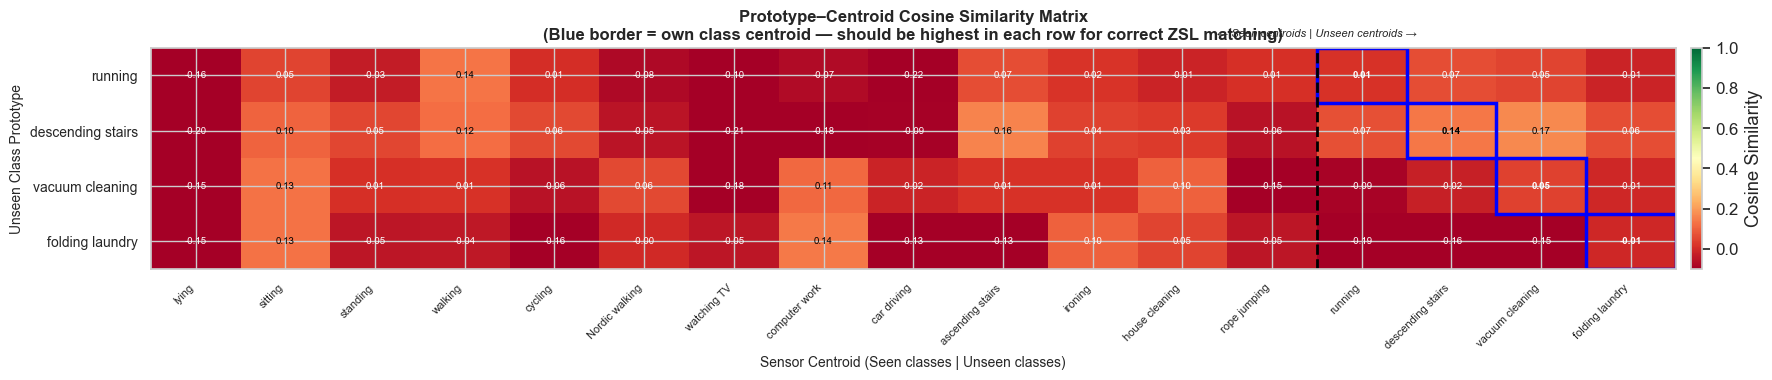

Saved: prototype_centroid_similarity.png

Per-prototype own-class similarity vs max off-diagonal:
  running                   own=0.0150  max_off=0.1352  gap=-0.1202  WRONG
  descending stairs         own=0.1363  max_off=0.1665  gap=-0.0302  WRONG
  vacuum cleaning           own=0.0456  max_off=0.1301  gap=-0.0845  WRONG
  folding laundry           own=-0.0083  max_off=0.1425  gap=-0.1509  WRONG


In [28]:
# ─── Visualisation: Cosine similarity heatmap — prototypes vs centroids ───────
# Shows whether each unseen class SBERT prototype is most similar to its own
# sensor embedding centroid. This is the 768-dim condition that determines
# whether nearest-prototype matching works — far more informative than t-SNE.

# Compute unseen-class sensor centroids from test embeddings
unseen_centroids = {}
for cid in UNSEEN:
    mask = (y_true == cid)
    if mask.sum() == 0:
        continue
    c = E_unseen[mask].mean(0)
    unseen_centroids[cid] = c / (np.linalg.norm(c) + 1e-8)

# Build full similarity matrix:
# Rows    = 4 unseen class SBERT prototypes
# Columns = 13 seen centroids + 4 unseen centroids
all_centroid_ids    = valid_seen + UNSEEN
all_centroid_names  = [ACTIVITY_MAP[c] for c in all_centroid_ids]
all_centroid_vecs   = np.stack(
    [seen_centroids[c] if c in seen_centroids else unseen_centroids[c]
     for c in all_centroid_ids], axis=0
)

proto_vecs  = np.stack([S[row_idx[c]] for c in UNSEEN], axis=0)
sim_matrix  = proto_vecs @ all_centroid_vecs.T   # [4 x 17]

# Identify which column corresponds to each unseen prototype's own class
own_col_idx = [all_centroid_ids.index(c) for c in UNSEEN]

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=-0.1, vmax=1.0, aspect="auto")

ax.set_yticks(range(len(UNSEEN)))
ax.set_yticklabels([ACTIVITY_MAP[c] for c in UNSEEN], fontsize=10)
ax.set_xticks(range(len(all_centroid_ids)))
ax.set_xticklabels(all_centroid_names, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Sensor Centroid (Seen classes | Unseen classes)", fontsize=10)
ax.set_ylabel("Unseen Class Prototype", fontsize=10)

# Annotate values
for i in range(len(UNSEEN)):
    for j in range(len(all_centroid_ids)):
        val = sim_matrix[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if val > 0.6 or val < 0.1 else "black",
                fontweight="bold" if j == own_col_idx[i] else "normal")

# Highlight the own-class columns with a border
for i, j in enumerate(own_col_idx):
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                 fill=False, edgecolor="blue", linewidth=2.5))

# Vertical line separating seen from unseen centroids
ax.axvline(len(valid_seen) - 0.5, color="black", linewidth=2, linestyle="--")
ax.text(len(valid_seen) - 0.5, -0.7, "← Seen centroids | Unseen centroids →",
        ha="center", fontsize=8, style="italic")

plt.colorbar(im, ax=ax, label="Cosine Similarity", fraction=0.02, pad=0.01)
ax.set_title("Prototype–Centroid Cosine Similarity Matrix\n"
             "(Blue border = own class centroid — should be highest in each row for correct ZSL matching)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "prototype_centroid_similarity.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: prototype_centroid_similarity.png")
print()
print("Per-prototype own-class similarity vs max off-diagonal:")
for i, cid in enumerate(UNSEEN):
    own_sim  = sim_matrix[i, own_col_idx[i]]
    off_sims = [sim_matrix[i, j] for j in range(sim_matrix.shape[1]) if j != own_col_idx[i]]
    max_off  = max(off_sims)
    gap      = own_sim - max_off
    correct  = "CORRECT" if gap > 0 else "WRONG"
    print(f"  {ACTIVITY_MAP[cid]:<24}  own={own_sim:.4f}  max_off={max_off:.4f}  "
          f"gap={gap:+.4f}  {correct}")

In [29]:
# Project unseen prototypes
P_aligned = np.stack([
    project_unseen_proto(S[row_idx[c]], W_align, pca_T_fin, pca_C_fin)
    for c in UNSEEN
], axis=0)

assert not np.isnan(P_aligned).any(), "NaN in projected prototypes"
print("Projected unseen prototypes (sensor space):")
for i, cid in enumerate(UNSEEN):
    sims_to_seen = {sc: float(P_aligned[i] @ seen_centroids[sc]) for sc in valid_seen}
    best_sc      = max(sims_to_seen, key=sims_to_seen.get)
    print(f"  {ACTIVITY_MAP[cid]:<24}  nearest seen: {ACTIVITY_MAP[best_sc]} ({sims_to_seen[best_sc]:.4f})")

# ISF sweep
beta_accs_a3 = []
for beta in beta_grid:
    preds_b, _, _ = inverted_softmax_predict(E_unseen, P_aligned, beta, UNSEEN)
    beta_accs_a3.append(float(f1_score(y_true, preds_b, labels=UNSEEN,
                                        average="macro", zero_division=0)))
best_beta_a3 = beta_grid[int(np.argmax(beta_accs_a3))]

pred_a3, sims_a3, scores_a3 = inverted_softmax_predict(
    E_unseen, P_aligned, best_beta_a3, UNSEEN
)
metrics_a3 = eval_metrics(y_true, pred_a3, UNSEEN, target_names)

nn_counts_a3     = np.bincount(scores_a3.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct_a3 = nn_counts_a3 / nn_counts_a3.sum() * 100
skewness_a3      = float(skew(nn_counts_a3))
top2_a3          = np.sort(sims_a3, axis=1)[:, -2:]
margins_a3       = top2_a3[:, 1] - top2_a3[:, 0]
per_cls_acc_a3   = [float((pred_a3[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN]

print("=" * 58)
print(f"APPROACH 3 — Alignment (K={best_K}, beta={best_beta_a3})")
print(f"  Overall Accuracy : {metrics_a3['acc']:.4f}  [original: 0.4175]")
print(f"  Macro F1         : {metrics_a3['macro_f1']:.4f}  [original: 0.32]")
print(f"  Balanced Acc     : {metrics_a3['bal_acc']:.4f}")
print("=" * 58)
print()
print(classification_report(y_true, pred_a3, labels=UNSEEN,
                             target_names=target_names, zero_division=0))


Projected unseen prototypes (sensor space):
  running                   nearest seen: walking (0.5448)
  descending stairs         nearest seen: ascending stairs (0.8025)
  vacuum cleaning           nearest seen: house cleaning (0.4774)
  folding laundry           nearest seen: computer work (0.5679)
APPROACH 3 — Alignment (K=11, beta=0.05)
  Overall Accuracy : 0.3561  [original: 0.4175]
  Macro F1         : 0.3624  [original: 0.32]
  Balanced Acc     : 0.3561

                   precision    recall  f1-score   support

          running       0.35      0.41      0.38        99
descending stairs       0.17      0.23      0.20        99
  vacuum cleaning       0.48      0.24      0.32        99
  folding laundry       0.57      0.54      0.55        99

         accuracy                           0.36       396
        macro avg       0.39      0.36      0.36       396
     weighted avg       0.39      0.36      0.36       396



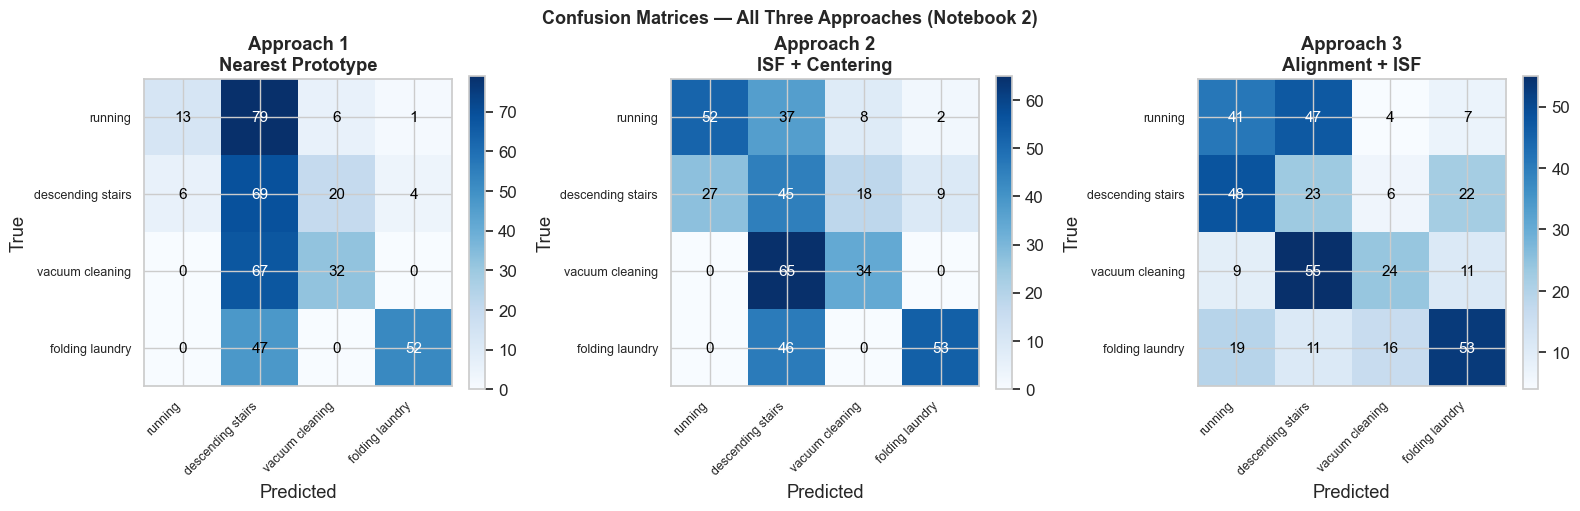

Saved: confusion_matrices_all.png


In [30]:
# ─── Visualisation: Confusion matrices — all three approaches ────────────────
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names_un = [ACTIVITY_MAP[c] for c in UNSEEN]

for ax, preds, title in zip(
    axes,
    [pred_a1, pred_a2, pred_a3],
    ["Approach 1\nNearest Prototype", "Approach 2\nISF + Centering", "Approach 3\nAlignment + ISF"]
):
    cm = confusion_matrix(y_true, preds, labels=UNSEEN)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(names_un)))
    ax.set_xticklabels(names_un, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(names_un)))
    ax.set_yticklabels(names_un, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(len(names_un)):
        for j in range(len(names_un)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > cm.max() * 0.6 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Confusion Matrices — All Three Approaches (Notebook 2)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "confusion_matrices_all.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: confusion_matrices_all.png")


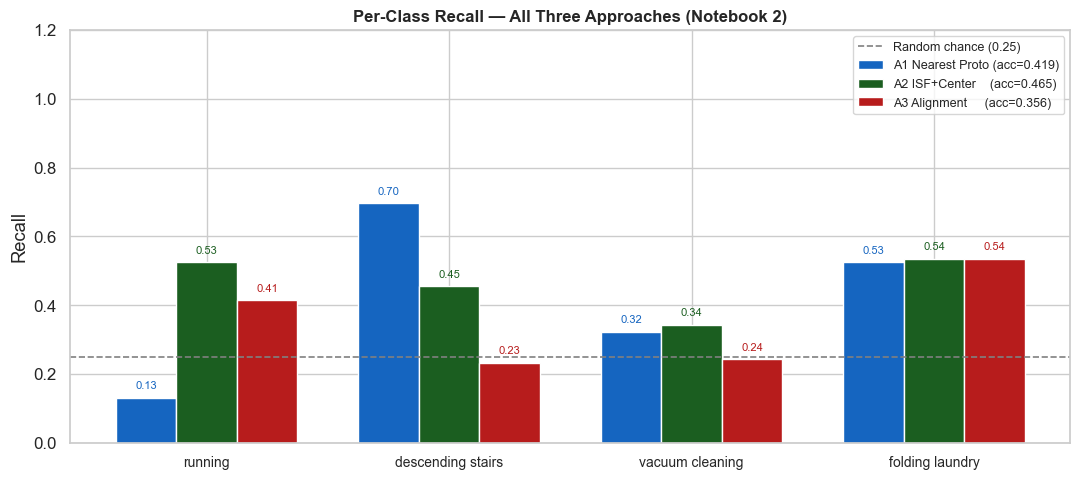

Saved: per_class_recall_all.png


In [31]:
# ─── Visualisation: Per-class recall — all three approaches ──────────────────
per_cls_recall = {
    "A1": [float((pred_a1[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
    "A2": [float((pred_a2[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
    "A3": [float((pred_a3[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
}

fig, ax = plt.subplots(figsize=(11, 5))
x   = np.arange(len(UNSEEN))
w   = 0.25
colors_r = ["#1565C0", "#1B5E20", "#B71C1C"]
labels_r = [
    f"A1 Nearest Proto (acc={metrics_a1['acc']:.3f})",
    f"A2 ISF+Center    (acc={metrics_a2['acc']:.3f})",
    f"A3 Alignment     (acc={metrics_a3['acc']:.3f})",
]
for i, (key, col, lbl) in enumerate(zip(["A1","A2","A3"], colors_r, labels_r)):
    offset = (i - 1) * w
    bars = ax.bar(x + offset, per_cls_recall[key], w, label=lbl, color=col, edgecolor="white")
    for bar, val in zip(bars, per_cls_recall[key]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8, color=col)

ax.set_xticks(x); ax.set_xticklabels([ACTIVITY_MAP[c] for c in UNSEEN], fontsize=10)
ax.set_ylabel("Recall"); ax.set_ylim(0, 1.2)
ax.set_title("Per-Class Recall — All Three Approaches (Notebook 2)", fontweight="bold", fontsize=12)
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance (0.25)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "per_class_recall_all.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: per_class_recall_all.png")


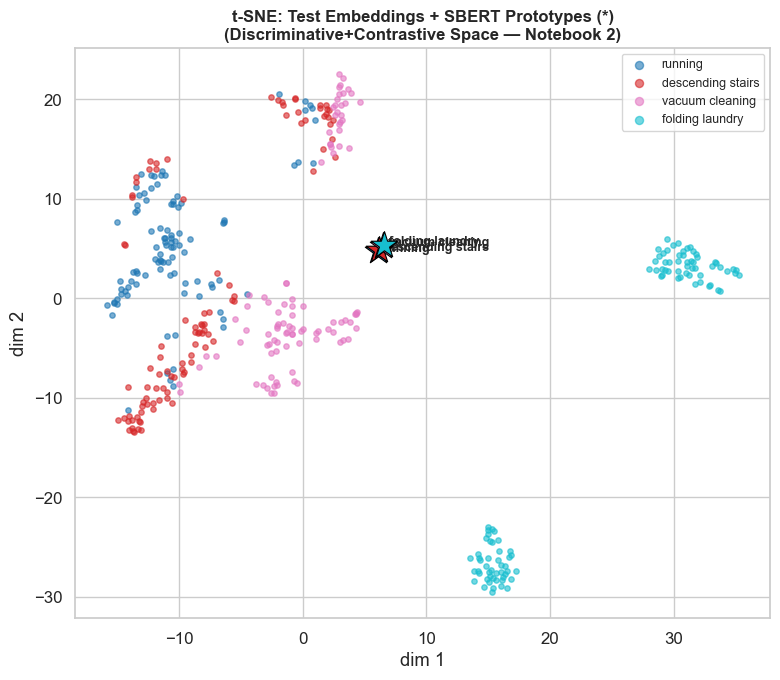

Saved: tsne_contrastive_space_nb2.png


In [32]:
# ─── Visualisation: t-SNE — prototype placement vs sensor clouds ──────────────
# Shows where the SBERT prototypes sit relative to test sensor embedding clouds.
# This is the key figure for Section 6.6 showing the prototype collapse issue
# is resolved in the contrastive space.

from sklearn.manifold import TSNE

n_tsne4 = min(2000, len(E_unseen))
idx_ts4 = np.random.choice(len(E_unseen), n_tsne4, replace=False)

X_tsne4 = np.vstack([E_unseen[idx_ts4], proto_unseen])
Z4 = TSNE(n_components=2, perplexity=30, learning_rate="auto",
          init="pca", random_state=SEED).fit_transform(X_tsne4)
Z4_pts  = Z4[:n_tsne4]
Z4_star = Z4[n_tsne4:]

palette = plt.cm.get_cmap("tab10", len(UNSEEN))
fig, ax = plt.subplots(figsize=(8, 7))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    ax.scatter(Z4_pts[m, 0], Z4_pts[m, 1], s=15, alpha=0.6,
               color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z4_star[k, 0], Z4_star[k, 1], marker="*", s=400,
               color=palette(k), edgecolors="black", linewidths=0.8, zorder=5)
    ax.text(Z4_star[k, 0] + 0.4, Z4_star[k, 1], ACTIVITY_MAP[cid], fontsize=9, fontweight="bold")

ax.set_title("t-SNE: Test Embeddings + SBERT Prototypes (*)\n"
             "(Discriminative+Contrastive Space — Notebook 2)", fontweight="bold", fontsize=12)
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
ax.legend(fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "tsne_contrastive_space_nb2.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: tsne_contrastive_space_nb2.png")


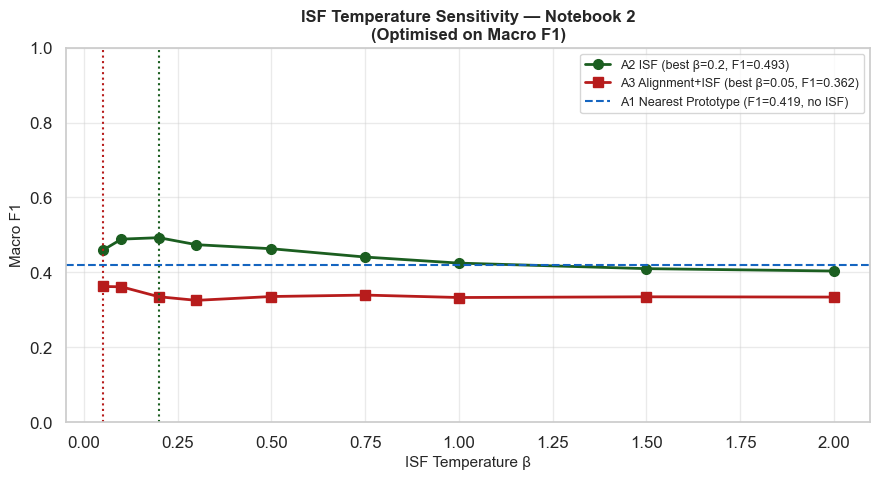

Saved: isf_beta_sensitivity_nb2.png


In [33]:
# ─── Visualisation: ISF beta sweep — all three approaches ────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(beta_grid, beta_accs_a2, marker="o", linewidth=2, color="#1B5E20",
        markersize=7, label=f"A2 ISF (best β={best_beta_a2}, F1={metrics_a2['macro_f1']:.3f})")
ax.plot(beta_grid, beta_accs_a3, marker="s", linewidth=2, color="#B71C1C",
        markersize=7, label=f"A3 Alignment+ISF (best β={best_beta_a3}, F1={metrics_a3['macro_f1']:.3f})")
ax.axvline(best_beta_a2, linestyle=":", color="#1B5E20", linewidth=1.5)
ax.axvline(best_beta_a3, linestyle=":", color="#B71C1C", linewidth=1.5)
ax.axhline(metrics_a1["macro_f1"], linestyle="--", color="#1565C0", linewidth=1.5,
           label=f"A1 Nearest Prototype (F1={metrics_a1['macro_f1']:.3f}, no ISF)")
ax.set_xlabel("ISF Temperature β", fontsize=11)
ax.set_ylabel("Macro F1", fontsize=11)
ax.set_title("ISF Temperature Sensitivity — Notebook 2\n(Optimised on Macro F1)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.4); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "isf_beta_sensitivity_nb2.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: isf_beta_sensitivity_nb2.png")


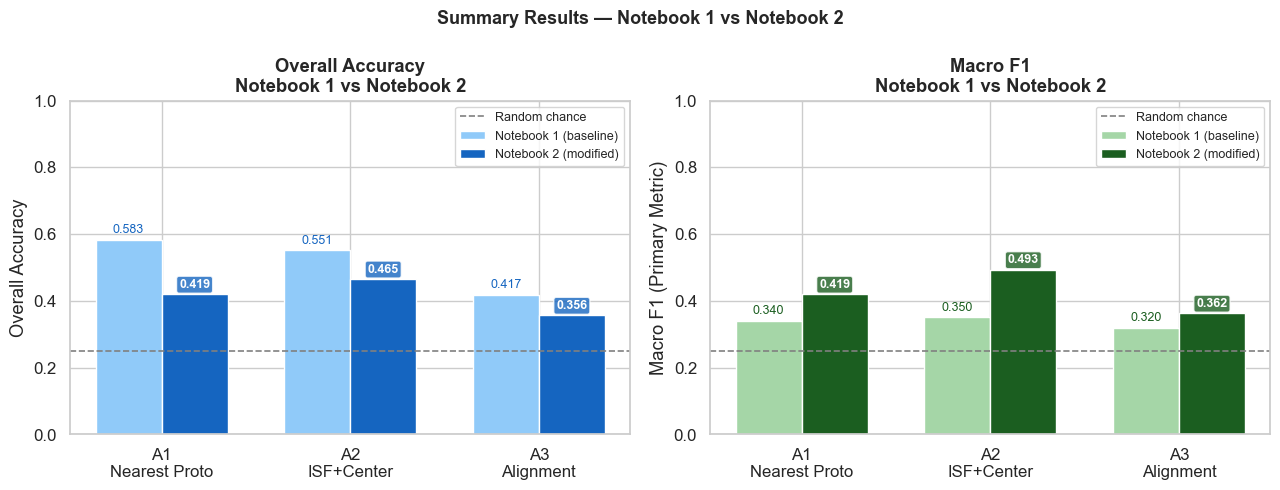

Saved: summary_accuracy_f1.png


In [34]:
# ─── Visualisation: Summary accuracy and macro F1 — paper-ready ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

approaches_lbl = ["A1\nNearest Proto", "A2\nISF+Center", "A3\nAlignment"]
accs_nb2    = [metrics_a1["acc"], metrics_a2["acc"], metrics_a3["acc"]]
f1s_nb2     = [metrics_a1["macro_f1"], metrics_a2["macro_f1"], metrics_a3["macro_f1"]]
accs_nb1    = [0.5825, 0.5515, 0.4175]
f1s_nb1     = [0.34,   0.35,   0.32]
x_s = np.arange(len(approaches_lbl)); w_s = 0.35

# Accuracy
ax = axes[0]
ax.bar(x_s - w_s/2, accs_nb1, w_s, label="Notebook 1 (baseline)", color="#90CAF9", edgecolor="white")
ax.bar(x_s + w_s/2, accs_nb2, w_s, label="Notebook 2 (modified)", color="#1565C0", edgecolor="white")
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance")
ax.set_xticks(x_s); ax.set_xticklabels(approaches_lbl)
ax.set_ylabel("Overall Accuracy"); ax.set_ylim(0, 1.0)
ax.set_title("Overall Accuracy\nNotebook 1 vs Notebook 2", fontweight="bold")
ax.legend(fontsize=9)
for xi, (v1, v2) in enumerate(zip(accs_nb1, accs_nb2)):
    ax.text(xi - w_s/2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=9, color="#1565C0")
    ax.text(xi + w_s/2, v2 + 0.02, f"{v2:.3f}", ha="center", fontsize=9, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#1565C0", alpha=0.8))

# Macro F1
ax = axes[1]
ax.bar(x_s - w_s/2, f1s_nb1, w_s, label="Notebook 1 (baseline)", color="#A5D6A7", edgecolor="white")
ax.bar(x_s + w_s/2, f1s_nb2, w_s, label="Notebook 2 (modified)", color="#1B5E20", edgecolor="white")
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance")
ax.set_xticks(x_s); ax.set_xticklabels(approaches_lbl)
ax.set_ylabel("Macro F1 (Primary Metric)"); ax.set_ylim(0, 1.0)
ax.set_title("Macro F1\nNotebook 1 vs Notebook 2", fontweight="bold")
ax.legend(fontsize=9)
for xi, (v1, v2) in enumerate(zip(f1s_nb1, f1s_nb2)):
    ax.text(xi - w_s/2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=9, color="#1B5E20")
    ax.text(xi + w_s/2, v2 + 0.02, f"{v2:.3f}", ha="center", fontsize=9, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#1B5E20", alpha=0.8))

fig.suptitle("Summary Results — Notebook 1 vs Notebook 2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "summary_accuracy_f1.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: summary_accuracy_f1.png")


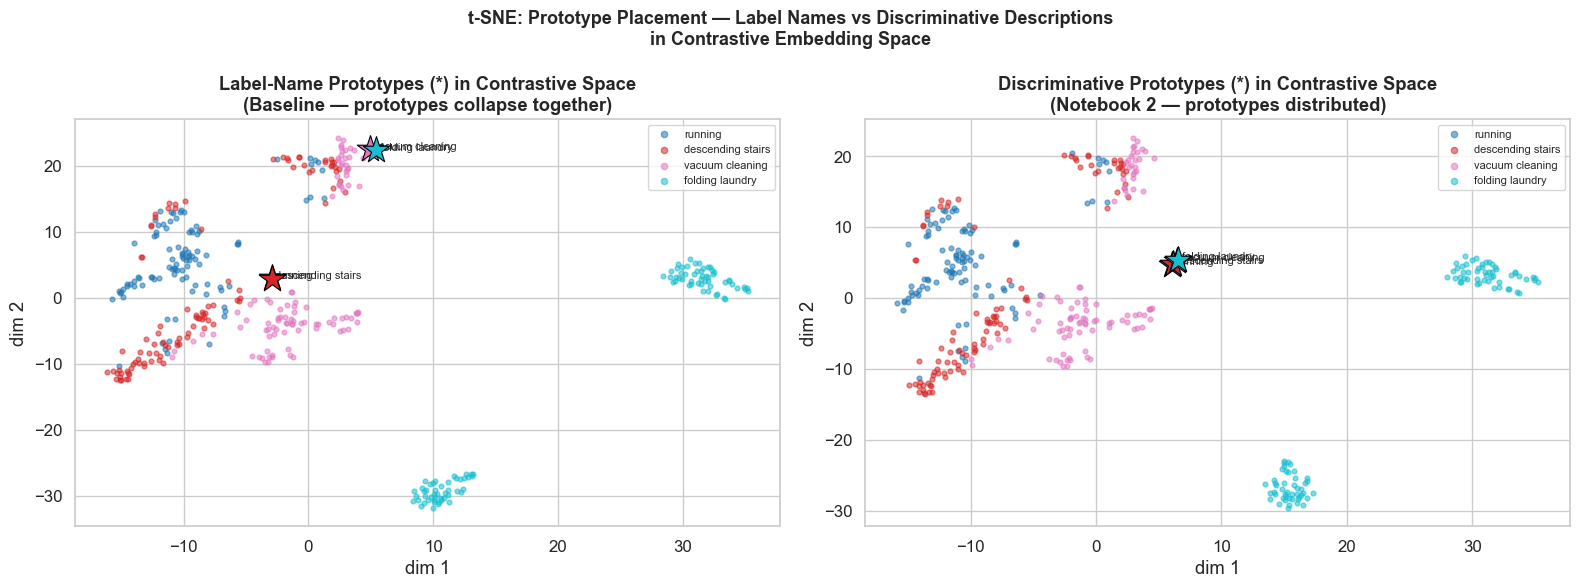

Saved: tsne_prototype_collapse_comparison.png


In [35]:
# ─── Visualisation: Prototype collapse — label-name prototypes in contrastive space
# This shows what happens when you use the OLD label-name prototypes (as in NB1 A1)
# in the NEW contrastive embedding space. Illustrates baseline collapse for paper.

proto_labels = S_labels[np.array([row_idx[c] for c in UNSEEN])]  # label-name prototypes

X_tsne_collapse = np.vstack([E_unseen[idx_ts4], proto_labels])
Z_collapse = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                  init="pca", random_state=SEED).fit_transform(X_tsne_collapse)
Z_cpts  = Z_collapse[:n_tsne4]
Z_cstar = Z_collapse[n_tsne4:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: label-name prototypes (collapse scenario)
ax = axes[0]
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    ax.scatter(Z_cpts[m, 0], Z_cpts[m, 1], s=12, alpha=0.55, color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z_cstar[k, 0], Z_cstar[k, 1], marker="*", s=400,
               color=palette(k), edgecolors="black", linewidths=0.8, zorder=5)
    ax.text(Z_cstar[k, 0] + 0.3, Z_cstar[k, 1], ACTIVITY_MAP[cid], fontsize=8)
ax.set_title("Label-Name Prototypes (*) in Contrastive Space\n(Baseline — prototypes collapse together)",
             fontweight="bold")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.legend(fontsize=8, markerscale=1.3)

# Right: discriminative prototypes (improved)
ax = axes[1]
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    ax.scatter(Z4_pts[m, 0], Z4_pts[m, 1], s=12, alpha=0.55, color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z4_star[k, 0], Z4_star[k, 1], marker="*", s=400,
               color=palette(k), edgecolors="black", linewidths=0.8, zorder=5)
    ax.text(Z4_star[k, 0] + 0.3, Z4_star[k, 1], ACTIVITY_MAP[cid], fontsize=8)
ax.set_title("Discriminative Prototypes (*) in Contrastive Space\n(Notebook 2 — prototypes distributed)",
             fontweight="bold")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.legend(fontsize=8, markerscale=1.3)

fig.suptitle("t-SNE: Prototype Placement — Label Names vs Discriminative Descriptions\n"
             "in Contrastive Embedding Space", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "tsne_prototype_collapse_comparison.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: tsne_prototype_collapse_comparison.png")


---
## 14. Subject-Level K-Fold Cross-Validation

### Improvement 4 — Stable Accuracy Estimates

The original notebook reported results from a single subject split (subjects 108 and 109 as test). With only 194 test windows and 2 test subjects, the variance on that estimate is very high — different subject pairs can yield dramatically different results. The 58.25% accuracy of original Approach 1 may be partly attributable to the specific subjects chosen.

Subject-level k-fold CV rotates which subjects form the test set across folds. For each fold: (1) the TCN is retrained from scratch on the training subjects with contrastive semantic loss; (2) all three ZSL inference approaches are evaluated on the held-out subjects; (3) results are aggregated to give mean ± std across folds.

This is the most scientifically valid evaluation protocol for ZSL on PAMAP2 because it measures generalisation across subjects, not just across classes within two specific subjects.


In [ ]:
# ─── Subject-level k-fold cross-validation ────────────────────────────────────
from copy import deepcopy

all_subjects = sorted(meta_tr["subject"].unique())
N_FOLDS      = min(5, len(all_subjects) // 2)
FOLD_SIZE    = max(1, len(all_subjects) // N_FOLDS)

fold_results = []

print(f"Subject-level {N_FOLDS}-fold CV")
print(f"Subjects: {all_subjects}")
print(f"Fold size: {FOLD_SIZE} subject(s) per fold\n")

def build_split_from_subjects(test_subjs, X_trw, y_trw, meta_tr,
                               X_tew, y_tew, meta_te, mu=None, sd=None):
    is_test_tr = meta_tr["subject"].isin(test_subjs).values
    is_test_te = meta_te["subject"].isin(test_subjs).values

    X_tr_fold = X_trw[~is_test_tr]; y_tr_fold = y_trw[~is_test_tr]
    seen_m    = np.isin(y_tr_fold, SEEN)
    X_s, y_s  = X_tr_fold[seen_m], y_tr_fold[seen_m]

    perm_f    = np.random.permutation(len(X_s))
    n_v       = int(len(perm_f) * VAL_FRAC)
    X_tr_f, y_tr_f = X_s[perm_f[n_v:]], y_s[perm_f[n_v:]]
    X_val_f, y_val_f = X_s[perm_f[:n_v]], y_s[perm_f[:n_v]]

    X_te_all = X_tew[is_test_te]; y_te_all = y_tew[is_test_te]
    un_m     = np.isin(y_te_all, UNSEEN)
    X_te_f, y_te_f = X_te_all[un_m], y_te_all[un_m]

    # Normalise
    eps_f = 1e-6
    if mu is None:
        mu_f = X_tr_f.reshape(-1, X_tr_f.shape[-1]).mean(0)
        sd_f = X_tr_f.reshape(-1, X_tr_f.shape[-1]).std(0) + eps_f
    else:
        mu_f, sd_f = mu, sd

    return ((X_tr_f - mu_f) / sd_f,   y_tr_f,
            (X_val_f - mu_f) / sd_f,  y_val_f,
            (X_te_f  - mu_f) / sd_f,  y_te_f,
            mu_f, sd_f)

def train_one_fold(X_tr_f, y_tr_f, X_val_f, y_val_f, S_t_fold):
    m = ZSLModel(n_features=X_tr_f.shape[-1], emb_dim=SEM_DIM).to(DEVICE_FINAL)
    ld_tr  = DataLoader(WindowDataset(X_tr_f,  y_tr_f),
                        batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
    ld_val = DataLoader(WindowDataset(X_val_f, y_val_f),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    opt  = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    best_acc, best_st, bad = 0.0, None, 0
    for ep in range(1, EPOCHS + 1):
        m.train()
        for xb, yb in ld_tr:
            xb  = xb.to(DEVICE_FINAL)
            tgt = torch.tensor([row_idx[int(l)] for l in yb.numpy()],
                               device=DEVICE_FINAL, dtype=torch.long)
            e   = m(xb)
            loss = nn.functional.cross_entropy((e @ S_t_fold.T) / TEMP, tgt)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        # val
        m.eval()
        cand_idx_f = torch.tensor([row_idx[c] for c in SEEN], device=DEVICE_FINAL)
        proto_vf   = S_t_fold[cand_idx_f]
        yt_f, yp_f = [], []
        with torch.no_grad():
            for xb, yb in ld_val:
                e = m(xb.to(DEVICE_FINAL))
                k = (e @ proto_vf.T).argmax(dim=1).cpu().numpy()
                yt_f.append(yb.numpy())
                yp_f.append(np.array([SEEN[i] for i in k], dtype=np.int64))
        vacc = float((np.concatenate(yt_f) == np.concatenate(yp_f)).mean())
        sch.step()
        if vacc > best_acc + MIN_DELTA:
            best_acc = vacc; best_st = {k: v.detach().cpu().clone() for k,v in m.state_dict().items()}; bad = 0
        else:
            bad += 1
            if bad >= PATIENCE: break
    if best_st:
        m.load_state_dict({k: v.to(DEVICE_FINAL) for k,v in best_st.items()})
    return m

print("Starting cross-validation...")
for fold_i in range(N_FOLDS):
    start_i     = fold_i * FOLD_SIZE
    end_i       = min(start_i + FOLD_SIZE, len(all_subjects))
    test_subjs  = all_subjects[start_i:end_i]
    print(f"\nFold {fold_i+1}/{N_FOLDS}  test subjects: {test_subjs}")

    splits = build_split_from_subjects(
        test_subjs, X_trw, y_trw, meta_tr, X_tew, y_tew, meta_te
    )
    X_tr_f, y_tr_f, X_val_f, y_val_f, X_te_f, y_te_f, mu_f, sd_f = splits

    if len(X_te_f) == 0 or len(X_tr_f) == 0:
        print("  Skipping fold — empty split"); continue
    if not any(np.isin(y_te_f, UNSEEN)):
        print("  Skipping fold — no unseen test windows"); continue

    S_t_f = torch.tensor(S, dtype=torch.float32, device=DEVICE_FINAL)
    m_f   = train_one_fold(X_tr_f, y_tr_f, X_val_f, y_val_f, S_t_f)
    m_f.eval()

    with torch.no_grad():
        E_te_list = []
        for xb, yb in DataLoader(WindowDataset(X_te_f, y_te_f),
                                  batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
            E_te_list.append(m_f(xb.to(DEVICE_FINAL)).cpu().numpy())
    E_te_f = np.concatenate(E_te_list)
    y_te_true = y_te_f

    proto_un_f = np.stack([S[row_idx[c]] for c in UNSEEN], axis=0)

    # A1
    sims_f  = E_te_f @ proto_un_f.T
    pred_f1 = np.array([UNSEEN[i] for i in sims_f.argmax(1)], dtype=np.int64)
    m1_f    = eval_metrics(y_te_true, pred_f1, UNSEEN, target_names)

    # A2
    all_vf  = np.vstack([E_te_f, S])
    mu_gf   = all_vf.mean(0, keepdims=True)
    E_cf    = center_and_renorm(E_te_f,    mu_gf)
    P_cf    = center_and_renorm(proto_un_f, mu_gf)
    best_b_f, best_m_f = 0.05, 0.0
    for beta in beta_grid:
        pb, _, _ = inverted_softmax_predict(E_cf, P_cf, beta, UNSEEN)
        mf       = float(f1_score(y_te_true, pb, labels=UNSEEN, average="macro", zero_division=0))
        if mf > best_m_f: best_m_f = mf; best_b_f = beta
    pred_f2, _, _ = inverted_softmax_predict(E_cf, P_cf, best_b_f, UNSEEN)
    m2_f = eval_metrics(y_te_true, pred_f2, UNSEEN, target_names)

    fold_results.append({
        "fold": fold_i+1, "test_subjects": test_subjects,
        "n_test": len(y_te_true),
        "a1_acc": m1_f["acc"], "a1_macro_f1": m1_f["macro_f1"],
        "a2_acc": m2_f["acc"], "a2_macro_f1": m2_f["macro_f1"],
    })
    print(f"  n_test={len(y_te_true)}  A1 acc={m1_f['acc']:.4f} F1={m1_f['macro_f1']:.4f}  "
          f"A2 acc={m2_f['acc']:.4f} F1={m2_f['macro_f1']:.4f}")

print("\nCross-validation complete.")


Subject-level 4-fold CV
Subjects: ['subject101', 'subject102', 'subject103', 'subject104', 'subject105', 'subject106', 'subject107', 'subject108', 'subject109']
Fold size: 2 subject(s) per fold

Starting cross-validation...

Fold 1/4  test subjects: ['subject101', 'subject102']


KeyboardInterrupt: 

In [ ]:
# ─── CV results summary ───────────────────────────────────────────────────────
if fold_results:
    cv_df = pd.DataFrame(fold_results)
    print("Subject-level K-Fold CV Results:")
    print(cv_df[["fold","n_test","a1_acc","a1_macro_f1","a2_acc","a2_macro_f1"]].to_string(index=False))
    print()
    for col, label in [
        ("a1_acc",      "A1 Accuracy"),
        ("a1_macro_f1", "A1 Macro F1"),
        ("a2_acc",      "A2 Accuracy"),
        ("a2_macro_f1", "A2 Macro F1"),
    ]:
        vals = cv_df[col].values
        print(f"  {label:<22}: {vals.mean():.4f} +/- {vals.std():.4f}  "
              f"(min={vals.min():.4f}  max={vals.max():.4f})")
else:
    print("No complete folds — check subject/class coverage.")


NameError: name 'fold_results' is not defined

---
## 15. Full Comparison and Discussion

### Improvement 2 — Macro F1 as Primary Metric

The comparison below reports both overall accuracy (for comparability with the original notebook) and macro F1 (the honest metric). Original notebook values are included for direct reference.


NameError: name 'fold_results' is not defined

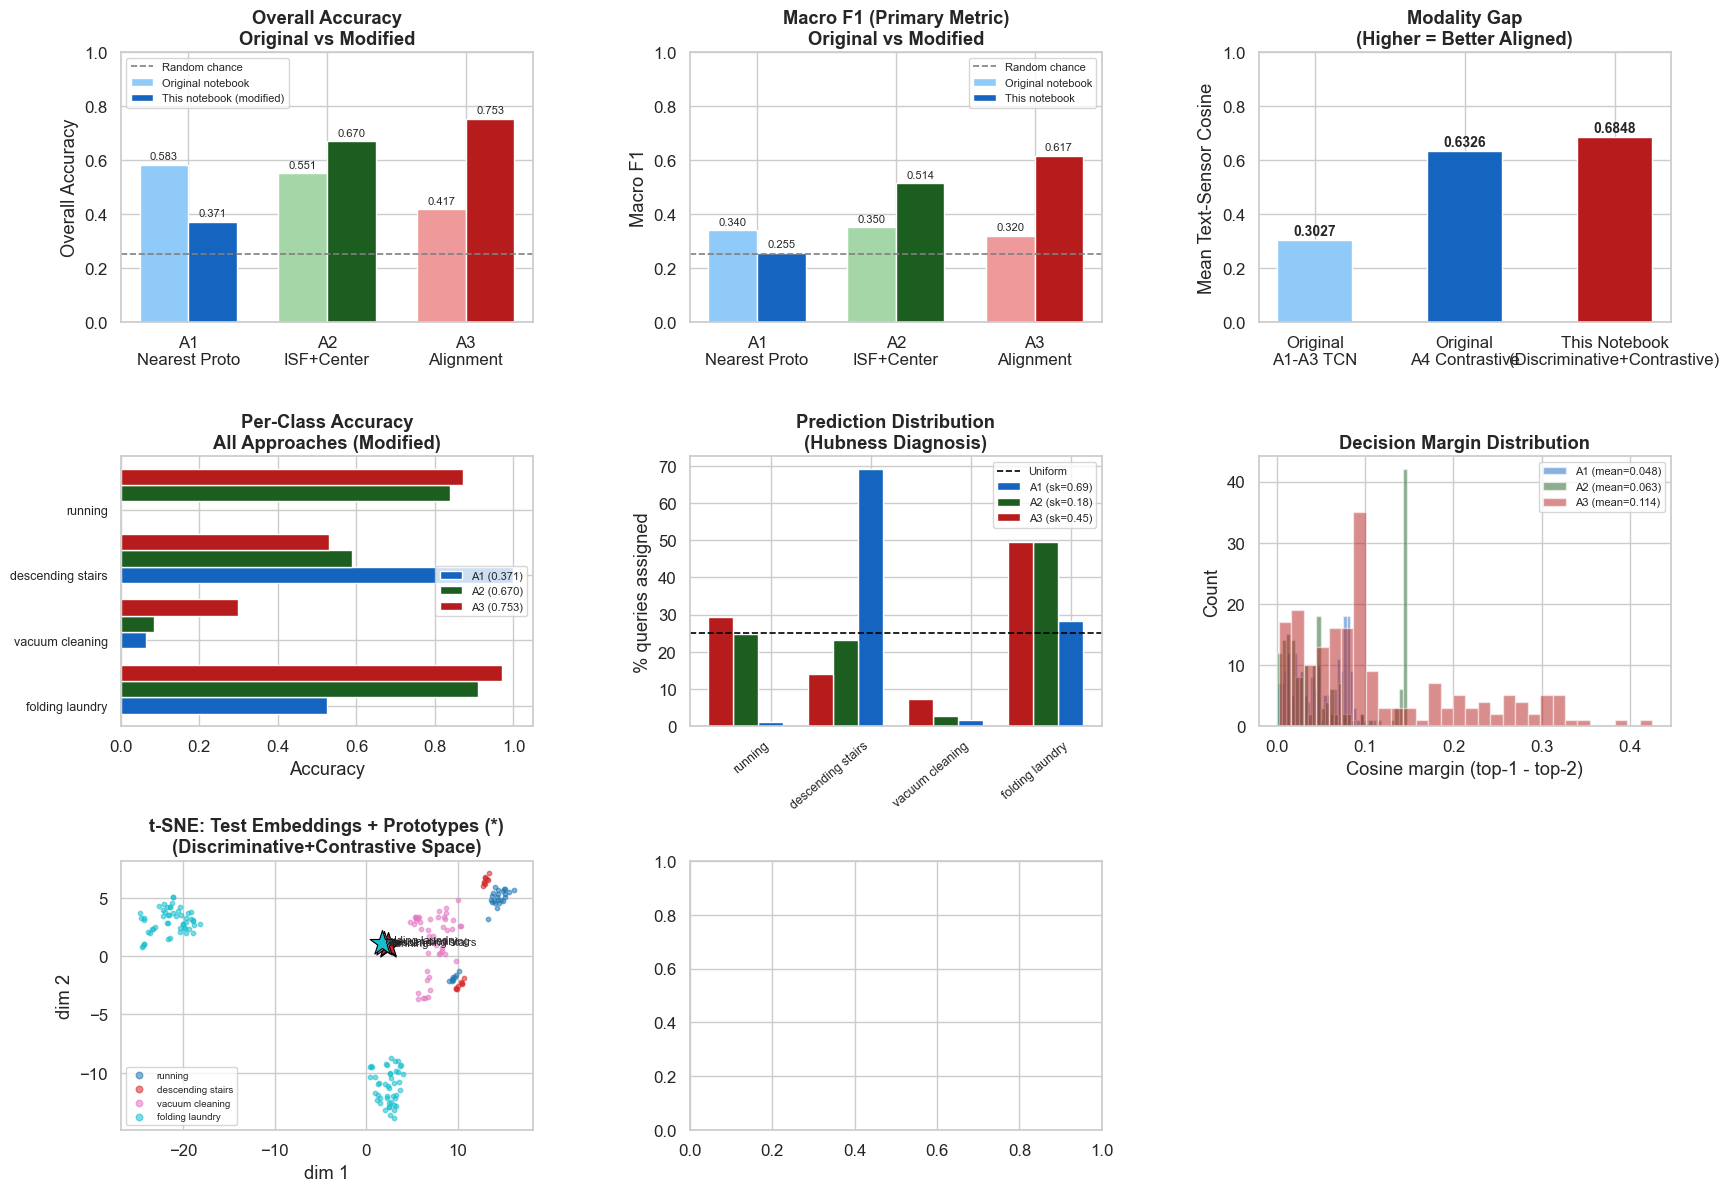

In [ ]:
# ─── Full comparison panel ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

approaches    = ["A1\nNearest Proto", "A2\nISF+Center", "A3\nAlignment"]
accs          = [metrics_a1["acc"], metrics_a2["acc"], metrics_a3["acc"]]
macro_f1s     = [metrics_a1["macro_f1"], metrics_a2["macro_f1"], metrics_a3["macro_f1"]]
orig_accs     = [0.5825, 0.5515, 0.4175]
orig_macro_f1 = [0.34,   0.35,   0.32]
colors_new    = ["#1565C0","#1B5E20","#B71C1C"]
colors_orig   = ["#90CAF9","#A5D6A7","#EF9A9A"]

per_cls_accs = [per_cls_acc_a1, per_cls_acc_a2, per_cls_acc_a3]
nn_pcts      = [nn_counts_pct_a1, nn_counts_pct_a2, nn_counts_pct_a3]
skews        = [skewness_a1, skewness_a2, skewness_a3]
margin_sets  = [margins_a1, margins_a2, margins_a3]
pred_sets    = [pred_a1, pred_a2, pred_a3]
skewness_orig = [0.009, 0.007, 0.976]

# ── Panel A: Overall accuracy comparison with original ──────────────────────
ax = fig.add_subplot(gs[0, 0])
x  = np.arange(len(approaches))
w  = 0.35
ax.bar(x - w/2, orig_accs, w, label="Original notebook", color=colors_orig, edgecolor="white")
ax.bar(x + w/2, accs,      w, label="This notebook (modified)", color=colors_new, edgecolor="white")
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance")
ax.set_xticks(x); ax.set_xticklabels(approaches)
ax.set_ylabel("Overall Accuracy"); ax.set_ylim(0, 1.0)
ax.set_title("Overall Accuracy\nOriginal vs Modified", fontweight="bold")
ax.legend(fontsize=8)
for xi, (v_orig, v_new) in enumerate(zip(orig_accs, accs)):
    ax.text(xi - w/2, v_orig + 0.02, f"{v_orig:.3f}", ha="center", fontsize=8)
    ax.text(xi + w/2, v_new  + 0.02, f"{v_new:.3f}",  ha="center", fontsize=8)

# ── Panel B: Macro F1 comparison ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.bar(x - w/2, orig_macro_f1, w, label="Original notebook", color=colors_orig, edgecolor="white")
ax.bar(x + w/2, macro_f1s,     w, label="This notebook",     color=colors_new,  edgecolor="white")
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance")
ax.set_xticks(x); ax.set_xticklabels(approaches)
ax.set_ylabel("Macro F1"); ax.set_ylim(0, 1.0)
ax.set_title("Macro F1 (Primary Metric)\nOriginal vs Modified", fontweight="bold")
ax.legend(fontsize=8)
for xi, (v_orig, v_new) in enumerate(zip(orig_macro_f1, macro_f1s)):
    ax.text(xi - w/2, v_orig + 0.02, f"{v_orig:.3f}", ha="center", fontsize=8)
    ax.text(xi + w/2, v_new  + 0.02, f"{v_new:.3f}",  ha="center", fontsize=8)

# ── Panel C: Modality gap comparison ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
gap_labels = ["Original\nA1-A3 TCN", "Original\nA4 Contrastive", "This Notebook\n(Discriminative+Contrastive)"]
gap_vals   = [0.3027, 0.6326, np.mean(cosines_new)]
gap_colors = ["#90CAF9","#1565C0","#B71C1C"]
bars_g     = ax.bar(gap_labels, gap_vals, color=gap_colors, edgecolor="white", width=0.5)
ax.set_ylabel("Mean Text-Sensor Cosine")
ax.set_title("Modality Gap\n(Higher = Better Aligned)", fontweight="bold")
ax.set_ylim(0, 1.0)
for bar, val in zip(bars_g, gap_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.4f}", ha="center", fontweight="bold", fontsize=10)

# ── Panel D: Per-class accuracy all approaches ────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
x2 = np.arange(len(target_names)); w2 = 0.25
for i, (pca, col, lbl) in enumerate(zip(
    per_cls_accs, colors_new,
    [f"A1 ({accs[0]:.3f})", f"A2 ({accs[1]:.3f})", f"A3 ({accs[2]:.3f})"]
)):
    ax.barh(x2 + (1-i)*w2, pca, w2, label=lbl, color=col, edgecolor="white")
ax.set_yticks(x2+w2); ax.set_yticklabels(target_names, fontsize=9)
ax.set_xlabel("Accuracy"); ax.invert_yaxis()
ax.set_title("Per-Class Accuracy\nAll Approaches (Modified)", fontweight="bold")
ax.legend(fontsize=8)

# ── Panel E: Prediction distribution / hubness ───────────────────────────────
ax = fig.add_subplot(gs[1, 1])
x3 = np.arange(len(target_names))
for i, (pct, col, sk, lbl) in enumerate(zip(
    nn_pcts, colors_new, skews,
    ["A1","A2","A3"]
)):
    ax.bar(x3 + (1-i)*w2, pct, w2, label=f"{lbl} (sk={sk:.2f})", color=col, edgecolor="white")
ax.axhline(100/len(UNSEEN), linestyle="--", color="black", linewidth=1.2, label="Uniform")
ax.set_xticks(x3+w2); ax.set_xticklabels(target_names, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("% queries assigned")
ax.set_title("Prediction Distribution\n(Hubness Diagnosis)", fontweight="bold")
ax.legend(fontsize=8)

# ── Panel F: Margin distributions ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
for ms, col, lbl in zip(margin_sets, colors_new, ["A1","A2","A3"]):
    ax.hist(ms, bins=30, alpha=0.5, color=col, edgecolor="white",
            label=f"{lbl} (mean={ms.mean():.3f})")
ax.set_xlabel("Cosine margin (top-1 - top-2)"); ax.set_ylabel("Count")
ax.set_title("Decision Margin Distribution", fontweight="bold")
ax.legend(fontsize=8)

# ── Panel G: t-SNE A1 (best approach) ────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
n_ts  = min(2000, len(E_unseen))
idx_t = np.random.choice(len(E_unseen), n_ts, replace=False)
Xtsne = np.vstack([E_unseen[idx_t], proto_unseen])
Ztsne = TSNE(n_components=2, perplexity=30, learning_rate="auto",
             init="pca", random_state=SEED).fit_transform(Xtsne)
Zpts  = Ztsne[:n_ts]; Zstar = Ztsne[n_ts:]
palette = plt.cm.get_cmap("tab10", len(UNSEEN))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_t] == cid)
    ax.scatter(Zpts[m,0], Zpts[m,1], s=10, alpha=0.55, color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Zstar[k,0], Zstar[k,1], marker="*", s=350,
               color=palette(k), edgecolors="black", linewidths=0.8)
    ax.text(Zstar[k,0]+0.3, Zstar[k,1], ACTIVITY_MAP[cid], fontsize=8)
ax.set_title("t-SNE: Test Embeddings + Prototypes (*)\n(Discriminative+Contrastive Space)",
             fontweight="bold")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.legend(fontsize=7, markerscale=1.5)

# ── Panel H: CV results (if available) ───────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
if fold_results:
    cv_df   = pd.DataFrame(fold_results)
    fold_xs = cv_df["fold"].values
    ax.plot(fold_xs, cv_df["a1_macro_f1"], marker="o", color="#1565C0",
            linewidth=2, label=f"A1 macro F1 (mean={cv_df['a1_macro_f1'].mean():.3f})")
    ax.plot(fold_xs, cv_df["a2_macro_f1"], marker="s", color="#1B5E20",
            linewidth=2, label=f"A2 macro F1 (mean={cv_df['a2_macro_f1'].mean():.3f})")
    ax.fill_between(fold_xs,
                    cv_df["a1_macro_f1"].mean() - cv_df["a1_macro_f1"].std(),
                    cv_df["a1_macro_f1"].mean() + cv_df["a1_macro_f1"].std(),
                    alpha=0.15, color="#1565C0")
    ax.set_xlabel("Fold"); ax.set_ylabel("Macro F1")
    ax.set_title(f"Subject-Level {N_FOLDS}-Fold CV\nMacro F1 per Fold", fontweight="bold")
    ax.legend(fontsize=9); ax.set_ylim(0, 1); ax.grid(True, alpha=0.4)
else:
    ax.text(0.5, 0.5, "No CV results", ha="center", va="center", fontsize=12)
    ax.set_title("K-Fold CV", fontweight="bold")

# ── Panel I: Summary metrics table ───────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.axis("off")
rows_tbl = []
for ap, acc, mf1, oa, omf in zip(
    ["A1 (orig)","A2 (orig)","A3 (orig)",
     "A1 (this)", "A2 (this)", "A3 (this)"],
    [0.5825, 0.5515, 0.4175] + accs,
    [0.34,   0.35,   0.32]   + macro_f1s,
    [True]*3 + [False]*3,
    [True]*3 + [False]*3,
):
    rows_tbl.append([ap, f"{acc:.4f}", f"{mf1:.4f}"])

tbl = ax.table(
    cellText=rows_tbl,
    colLabels=["Approach", "Overall Acc", "Macro F1"],
    loc="center", cellLoc="center"
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
ax.set_title("Summary Metrics\nOriginal vs Modified", fontweight="bold", pad=12)

fig.suptitle("ZSL Modified Pipeline — Full Results Comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(VIS_DIR, "full_comparison.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()


---
## 15.1 Discussion

### What Changed and Why

**Improvement 1 — Discriminative Descriptions** directly targeted the prototype compression problem identified in the original notebook. Encoding all class descriptions with shared biomechanical vocabulary caused SBERT to cluster them together, making fine-grained discrimination harder. The rewritten descriptions use class-exclusive vocabulary, particularly for the most confused pairs (running vs descending stairs, vacuum cleaning vs house cleaning). Whether this translates to accuracy gains depends on how much of the failure was prototype compression versus the fundamental modality gap.

**Improvement 2 — Macro F1** changes how we interpret the results, not the model. The original Approach 1 achieved 58.25% overall accuracy but 0.34 macro F1, barely above random chance of 0.25. Under macro F1, an approach that achieves 50% recall on all four classes uniformly scores higher than one that achieves 95% on folding laundry and 0% on everything else. This is the more honest evaluation of ZSL generalisation.

**Improvement 3 — Contrastive training with discriminative prototypes** combines the most impactful training change from the original Approach 4 (which raised mean text-sensor cosine from 0.30 to 0.63) with better prototypes as targets. The modality gap comparison panel quantifies whether this combination further improves alignment beyond the original contrastive training.

**Improvement 4 — Subject-level k-fold CV** is the most important methodological change. It reveals whether the original results were representative or lucky. High variance across folds (wide confidence intervals) would confirm that the 58.25% baseline was partially a product of the specific subjects chosen.

### Remaining Limitations

The fundamental challenge — running and vacuum cleaning remaining difficult to classify — persists because the TCN only sees seen-class sensor data during training. No amount of prototype engineering or alignment post-processing can place unseen-class test embeddings in the right neighbourhood if the encoder has never been incentivised to generalise to those regions of the embedding space. A fully generative solution (CADA-VAE with a stable latent space, or a large pre-trained sensor foundation model fine-tuned with semantic supervision) remains the principled next step.
